In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.graph_objects as go

from src.data_loading import load_class_data, int_to_label
from src.eda_utils import (
    plot_skewness,
    plot_kde_by_class,
    plot_histogram_by_class,
    plot_boxplot_by_class,
    plot_describe_table,
    plot_dataset_summary_table,
    remove_correlated_features,
    seleziona_variabili_pca,
)

## Uploading dei dati

In [ ]:
TRAIN_FEATURES_PATH = "../data/train_features_bone_marrow.h5"
TEST_FEATURES_PATH = "../data/test_features_bone_marrow.h5"

X_train, y_train = load_class_data(TRAIN_FEATURES_PATH)
X_test, y_test = load_class_data(TEST_FEATURES_PATH)

## Conversione a dataframe così da poter sfruttare le funzionalità di Pandas

In [ ]:
df_train = pd.DataFrame(X_train)
df_test = pd.DataFrame(X_test)

df_train[64] = y_train
df_test[64] = y_test

df_train[64] = df_train[64].astype('category').cat.codes #codifichiamo la variabile target come categoriale
df_test[64] = df_test[64].astype('category').cat.codes

#EDA


Assemblare i dati in una matrice organizzata in righe e colonne è solo il punto iniziale del trocesso. I dati vengono poi esaminati, esplorati, trasformati e infine inseriti in un modello.

Studiare e esplorare i dati è un passaggio cruciale del processo perchè da un'idea dei dati da gestire e i passaggi da poter attuare nel particolare caso studio.

L'EDA è un processo di esplorazione che ci permettere di scoprire come usare i nostri dati al meglio delle possibilità.

Partiamo con un approccio univariato studiando le features prese singolarmente attraverso statistiche descrittive e grafici, per poi passare all'approccio bivariato in cui esaminiamo come le features sono correlate tra loro; infine passiamo all'approccio multivariato di riduzione della dimensionalità in cui si cerca di dare uno sguardo generale a tutte le features insieme attraverso tecniche come PCA, t-SNE e UMAP.

I passaggi che seguiremo sono:
- Statistiche descrittive
- Distribuzione delle variabili
- Correlazioni tra le feature
- Studio di pattern e outliers
- Selezione variabili rilevanti
- Visualizzazione attraverso rappresentazioni 2D e 3D

##Statistiche descrittive
Inizio con un'analisi generale rispetto alla struttura sia del training set che del test set, di modo da comprendere la struttura dei dati da analizzare.

In [ ]:
df_train.shape

(44800, 65)

In [ ]:
#osserviamo le prime osservazioni del training set
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,-0.112201,-0.053106,-0.092745,0.036675,0.414105,-0.140362,-0.052791,-0.076956,0.000497,0.146117,...,0.017656,0.047259,-0.186327,-0.099781,-0.124640,-0.190558,-0.229757,0.003897,-0.001089,3
1,0.039911,-0.009121,-0.105657,-0.076587,0.207619,0.024891,0.048682,-0.352302,0.214481,0.054858,...,-0.118241,-0.157090,0.026378,0.180247,-0.088677,-0.069622,-0.064245,-0.269289,0.062619,2
2,0.179631,-0.022264,0.059510,0.072634,-0.008375,-0.015225,-0.063324,0.000972,-0.194509,0.955842,...,0.022877,-0.064166,-0.130786,0.060407,-0.078771,0.005783,-0.141633,-0.073824,-0.216373,4
3,0.051834,-0.070872,-0.136929,0.034272,0.303436,0.054932,0.369292,-0.401975,-0.018037,0.012611,...,-0.276812,-0.135872,0.002562,0.465869,-0.077928,-0.046753,-0.067768,-0.175521,0.100835,2
4,-0.281375,-0.030024,0.077575,-0.030118,0.108725,0.330279,-0.199601,-0.094366,0.161307,-0.010097,...,-0.096760,-0.113727,-0.236611,-0.106010,-0.083110,-0.048337,-0.276774,-0.112365,-0.245229,3


In [ ]:
df_test.shape

(19201, 65)

In [ ]:
#procediamo con la descrizione del dataset, anche in questo caso procediamo
#prima col training set e poi col test set
df_train.describe()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
count,44800.000000,44800.000000,44800.000000,44800.000000,44800.000000,44800.000000,44800.000000,44800.000000,44800.000000,44800.000000,...,44800.000000,44800.000000,44800.000000,44800.000000,44800.000000,44800.000000,44800.000000,44800.000000,44800.000000,44800.000000
mean,-0.016977,-0.036620,0.048764,0.011967,0.014724,0.017559,0.023735,-0.025061,-0.007517,0.024671,...,-0.005888,-0.027427,-0.058772,0.007126,-0.003728,-0.023912,-0.103851,-0.031155,-0.040530,2.430558
std,0.163767,0.139420,0.243670,0.178409,0.174214,0.199383,0.216369,0.157022,0.161752,0.208326,...,0.171954,0.136996,0.137610,0.184646,0.178897,0.196899,0.109195,0.141156,0.134855,0.772441
min,-0.429819,-0.669068,-0.370348,-0.490838,-0.413364,-0.405911,-0.553222,-0.472695,-0.598629,-0.370005,...,-0.435297,-0.453660,-0.421062,-0.447465,-0.353142,-0.414608,-0.399611,-0.476686,-0.462132,0.000000
25%,-0.120501,-0.103552,-0.075173,-0.077378,-0.073160,-0.090313,-0.099821,-0.127890,-0.113691,-0.091222,...,-0.103622,-0.112122,-0.157954,-0.111526,-0.119138,-0.168675,-0.170365,-0.127503,-0.119635,2.000000
50%,-0.020917,-0.036086,-0.003380,0.009003,0.007204,-0.012194,0.006649,-0.021927,-0.021896,-0.002626,...,-0.003527,-0.032365,-0.061939,-0.009316,-0.037031,-0.040397,-0.105264,-0.023305,-0.038253,2.000000
75%,0.065236,0.037395,0.092997,0.075844,0.068894,0.072907,0.096020,0.055786,0.076481,0.078369,...,0.063767,0.056939,0.028139,0.073914,0.083677,0.087905,-0.035546,0.049244,0.035115,3.000000
max,0.980816,0.975779,0.982349,0.973600,0.980383,0.982128,0.984097,0.980800,0.976959,0.982590,...,0.982935,0.972769,0.970485,0.977567,0.984076,0.977472,0.586485,0.973301,0.974720,4.000000


In [ ]:
df_test.describe()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
count,19201.000000,19201.000000,19201.000000,19201.000000,19201.000000,19201.000000,19201.000000,19201.000000,19201.000000,19201.000000,...,19201.000000,19201.000000,19201.000000,19201.000000,19201.000000,19201.000000,19201.000000,19201.000000,19201.000000,19201.000000
mean,-0.008859,-0.041021,0.063796,0.021386,0.012561,0.016057,0.028074,-0.031198,-0.010949,0.032100,...,-0.003397,-0.024111,-0.070065,0.014750,-0.001723,-0.019980,-0.119907,-0.032564,-0.048279,2.430603
std,0.157118,0.140008,0.253862,0.181539,0.157117,0.201417,0.226484,0.164835,0.159939,0.212787,...,0.170498,0.128840,0.136999,0.192776,0.189873,0.214511,0.096962,0.135725,0.131030,0.772367
min,-0.447256,-0.683170,-0.409304,-0.532013,-0.419667,-0.519255,-0.511506,-0.513808,-0.540314,-0.364472,...,-0.410999,-0.483345,-0.489970,-0.381067,-0.430700,-0.465908,-0.388376,-0.467771,-0.490316,0.000000
25%,-0.110397,-0.114393,-0.082739,-0.082026,-0.078293,-0.105096,-0.112214,-0.137745,-0.118515,-0.096428,...,-0.108607,-0.109374,-0.158342,-0.111696,-0.122091,-0.168740,-0.181829,-0.121334,-0.133722,2.000000
50%,-0.018360,-0.047135,-0.009449,0.002402,-0.001099,-0.023338,-0.010753,-0.040266,-0.029986,-0.012175,...,-0.011695,-0.030051,-0.076042,-0.021661,-0.037844,-0.053688,-0.119181,-0.035755,-0.052254,2.000000
75%,0.065656,0.031140,0.109577,0.084213,0.071795,0.073414,0.097384,0.046908,0.069968,0.083408,...,0.063726,0.055183,0.007924,0.076240,0.067298,0.079465,-0.056130,0.041452,0.024827,3.000000
max,0.972125,0.919174,0.977632,0.957100,0.975267,0.976588,0.979677,0.976124,0.956355,0.979611,...,0.968918,0.944891,0.959738,0.971321,0.966212,0.973054,0.289624,0.972527,0.938980,4.000000


In [ ]:
# Informazioni generali sul dataset
df_info = df_train.info()

# Contiamo i valori nulli in ogni colonna
missing_values = df_train.isnull().sum().sum()

# Dimensioni del dataset
shape = df_train.shape

df_info, missing_values, shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44800 entries, 0 to 44799
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       44800 non-null  float64
 1   1       44800 non-null  float64
 2   2       44800 non-null  float64
 3   3       44800 non-null  float64
 4   4       44800 non-null  float64
 5   5       44800 non-null  float64
 6   6       44800 non-null  float64
 7   7       44800 non-null  float64
 8   8       44800 non-null  float64
 9   9       44800 non-null  float64
 10  10      44800 non-null  float64
 11  11      44800 non-null  float64
 12  12      44800 non-null  float64
 13  13      44800 non-null  float64
 14  14      44800 non-null  float64
 15  15      44800 non-null  float64
 16  16      44800 non-null  float64
 17  17      44800 non-null  float64
 18  18      44800 non-null  float64
 19  19      44800 non-null  float64
 20  20      44800 non-null  float64
 21  21      44800 non-null  float64
 22

(None, np.int64(0), (44800, 65))

In [ ]:
# Informazioni generali sul dataset
df_info = df_test.info()

# Contiamo i valori nulli in ogni colonna
missing_values = df_test.isnull().sum().sum()

# Dimensioni del dataset
shape = df_test.shape

df_info, missing_values, shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19201 entries, 0 to 19200
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       19201 non-null  float64
 1   1       19201 non-null  float64
 2   2       19201 non-null  float64
 3   3       19201 non-null  float64
 4   4       19201 non-null  float64
 5   5       19201 non-null  float64
 6   6       19201 non-null  float64
 7   7       19201 non-null  float64
 8   8       19201 non-null  float64
 9   9       19201 non-null  float64
 10  10      19201 non-null  float64
 11  11      19201 non-null  float64
 12  12      19201 non-null  float64
 13  13      19201 non-null  float64
 14  14      19201 non-null  float64
 15  15      19201 non-null  float64
 16  16      19201 non-null  float64
 17  17      19201 non-null  float64
 18  18      19201 non-null  float64
 19  19      19201 non-null  float64
 20  20      19201 non-null  float64
 21  21      19201 non-null  float64
 22

(None, np.int64(0), (19201, 64))

I nostri dataset contengono 65 variabili di cui una (l'ultima) rappresenta le labels, ovvero la classificazione delle cellule (il tipo di cellula rappresentato in foto), mentre le altre 64 sono variabili numeriche, per l'esattezza di tipo float64 e sappiamo essere le caratteristiche delle immagini estratte tramite intelligenza artificiale che ci permetteranno di classificare il gruppo di appartenenza di una determinata cellula.

Il training test presenta 44800 osservazioni, mentre il test set 19201.

Non sono presenti missing values.

Tutte le variabili numeriche hanno osservazioni comprese nel range [-1;1]

##Distribuzione delle variabili
Concentriamo l'analisi sul training set in quanto sarà il dataset che useremo per addestrare i dati, ci aspettiamo che i risultati siano simili anche per il test set, siccome proviene dalla stessa popolazione

Inizio l'analisi con l'individuare la frequenza delle osservazioni appartenenti alle varie classi del training set sia analiticamente che con un barplot e piechart

In [ ]:
import matplotlib.patches as mpatches

colori = ['tomato',
          'deeppink',
          'gold',
          'limegreen',
          'deepskyblue']

color_map = {0: 'tomato', 1: 'deeppink', 2:'gold', 3:'limegreen', 4:'deepskyblue'}
categorie = ['BAS', 'EBO', 'EOS', 'LYT', 'MON']

In [ ]:
# Frequenza assoluta
frequenze_assolute = df_train[64].value_counts()
print("Frequenze assolute:\n", frequenze_assolute)
frequenze_assolute = frequenze_assolute.sort_index()
categorie = frequenze_assolute.index.tolist()

# Frequenza relativa (percentuale)
frequenze_relative = df_train[64].value_counts(normalize=True) * 100
print("\nFrequenze relative (%):\n", frequenze_relative.round(2))


Frequenze assolute:
 64
2    19176
3    18369
1     4118
4     2828
0      309
Name: count, dtype: int64

Frequenze relative (%):
 64
2    42.80
3    41.00
1     9.19
4     6.31
0     0.69
Name: proportion, dtype: float64


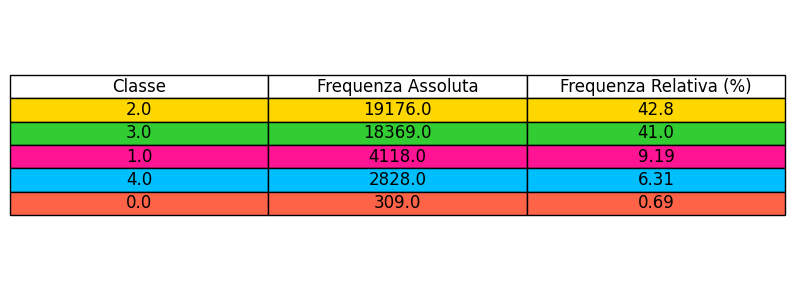

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Dati delle frequenze
frequenze_assolute = {2: 19176, 3: 18369, 1: 4118, 4: 2828, 0: 309}
frequenze_relative = {2: 42.80, 3: 41.00, 1: 9.19, 4: 6.31, 0: 0.69}

# Crea DataFrame
df_freq = pd.DataFrame({
    'Classe': list(frequenze_assolute.keys()),
    'Frequenza Assoluta': list(frequenze_assolute.values()),
    'Frequenza Relativa (%)': [frequenze_relative[k] for k in frequenze_assolute.keys()]
})

# Mappa colori per classi
color_map = {0: 'tomato', 1: 'deeppink', 2: 'gold', 3: 'limegreen', 4: 'deepskyblue'}

# Crea la figura
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
ax.axis('tight')

# Crea la tabella con colori per riga
table = ax.table(
    cellText=df_freq.values,
    colLabels=df_freq.columns,
    loc='center',
    cellLoc='center'
)

# Applica i colori alle righe (escludi intestazione)
for i, classe in enumerate(df_freq['Classe'], start=1):
    color = color_map[classe]
    for j in range(len(df_freq.columns)):
        table[(i, j)].set_facecolor(color)
        table[(i, j)].set_text_props(color='black')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Salva immagine
plt.tight_layout()
plt.savefig("frequenze_tabella_colori.png", dpi=300)
plt.show()


Il dataset è molto sbilanciato, la maggior parte delle osservazioni si hanno per le cellule di tipo 2 (Eosinofile) e 3 (Linfociti) , il tipo 0 (cellule Basofile) ha meno dell'1% di osservazioni

##Distribuzione delle features condizionate alla classe di appartenenza
Iniziamo a osservare la distribuzione della prima variabile condizionata ai 5 tipi di cellule, prima in modo continuo con la Kernel Density e poi in modo discreto con un istogramma

Per poter comparare tra loro le distribuzioni, ci conviene standardizzare le variabili in modo da avere una visualizzazione più chiara e che ci faccia capire la differenza tra le variabili ma anche tra le classi

In [ ]:


# Standardizzazione di tutte le colonne numeriche
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Ricostruzione del DataFrame standardizzato con la variabile target
df_train_std = pd.DataFrame(X_scaled)
df_train_std[64] = y_train

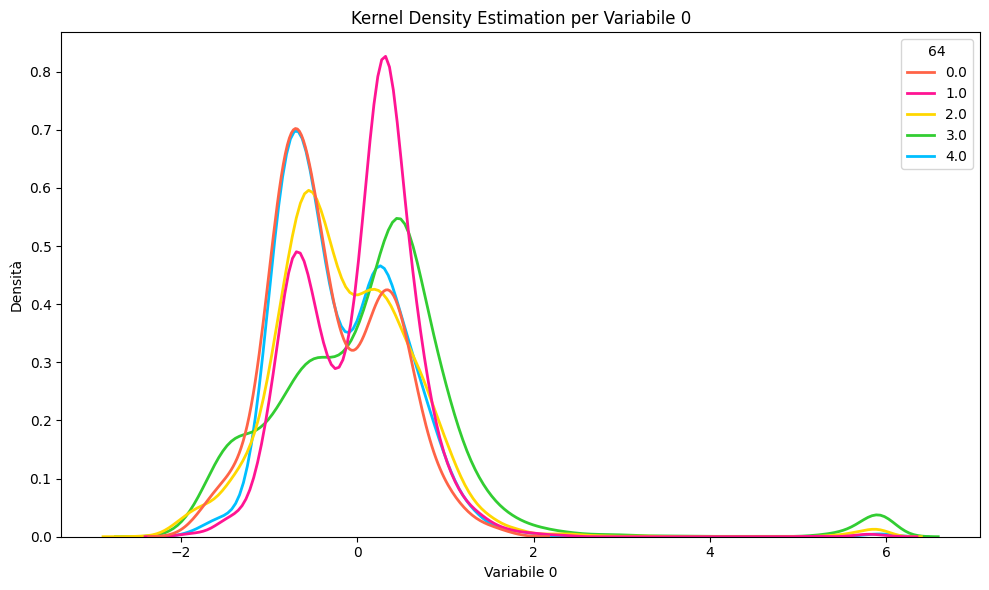

In [ ]:
plot_kde_by_class(df_train_std, 0, 64, colori, title='Kernel Density Estimation per Variabile 0')

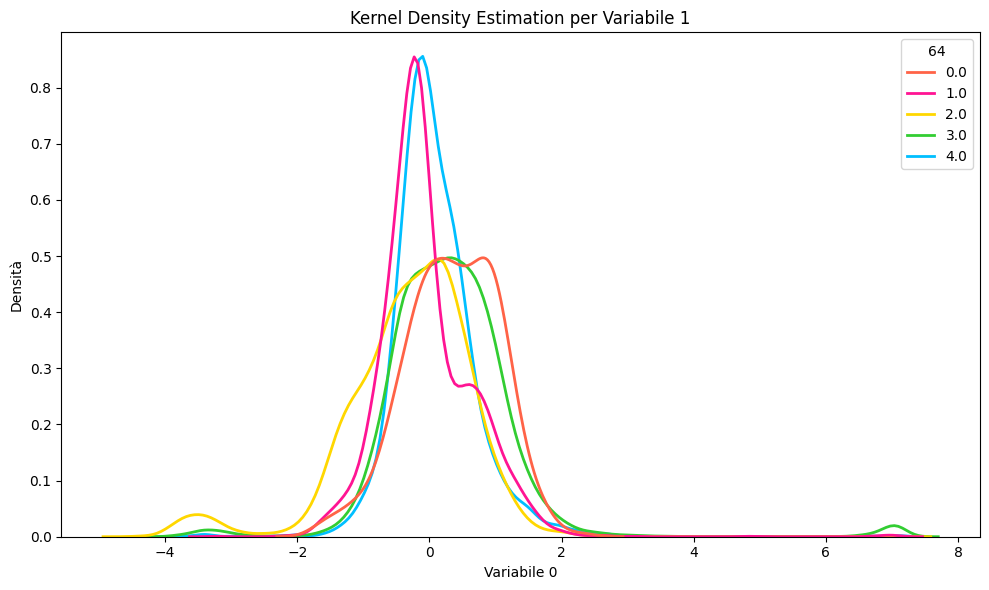

In [ ]:
plot_kde_by_class(df_train_std, 1, 64, colori, title='Kernel Density Estimation per Variabile 1')

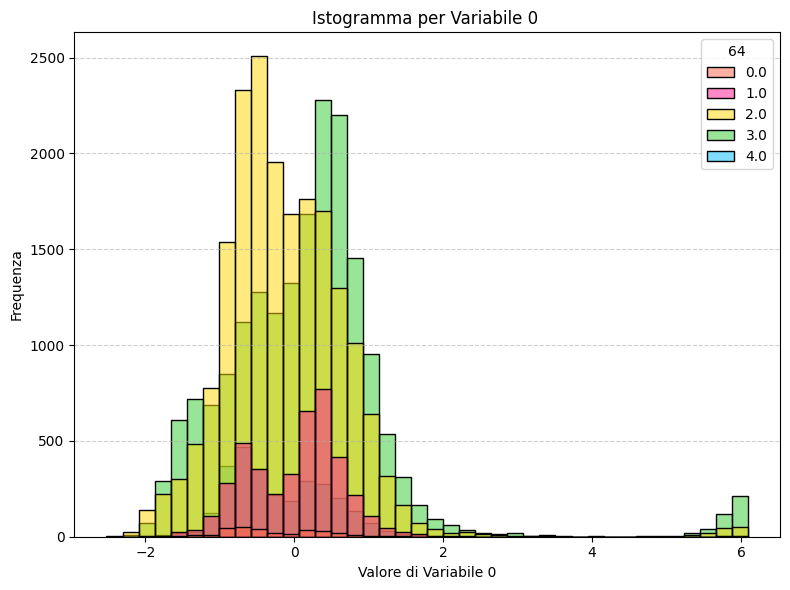

In [ ]:
plot_histogram_by_class(df_train_std, 0, 64, colori, bins=40, title='Istogramma per Variabile 0')

Abbiamo provato a osservare la distribuzione della prima variabile condizionata alle classi in modo discreto oltre che continuo, tuttavia la rappresenzatione risulta molto poco chiara, quindi continuiamo con l'analisi della distribuzione di tutte le altre features usando la kernel density (distribuzione continua).

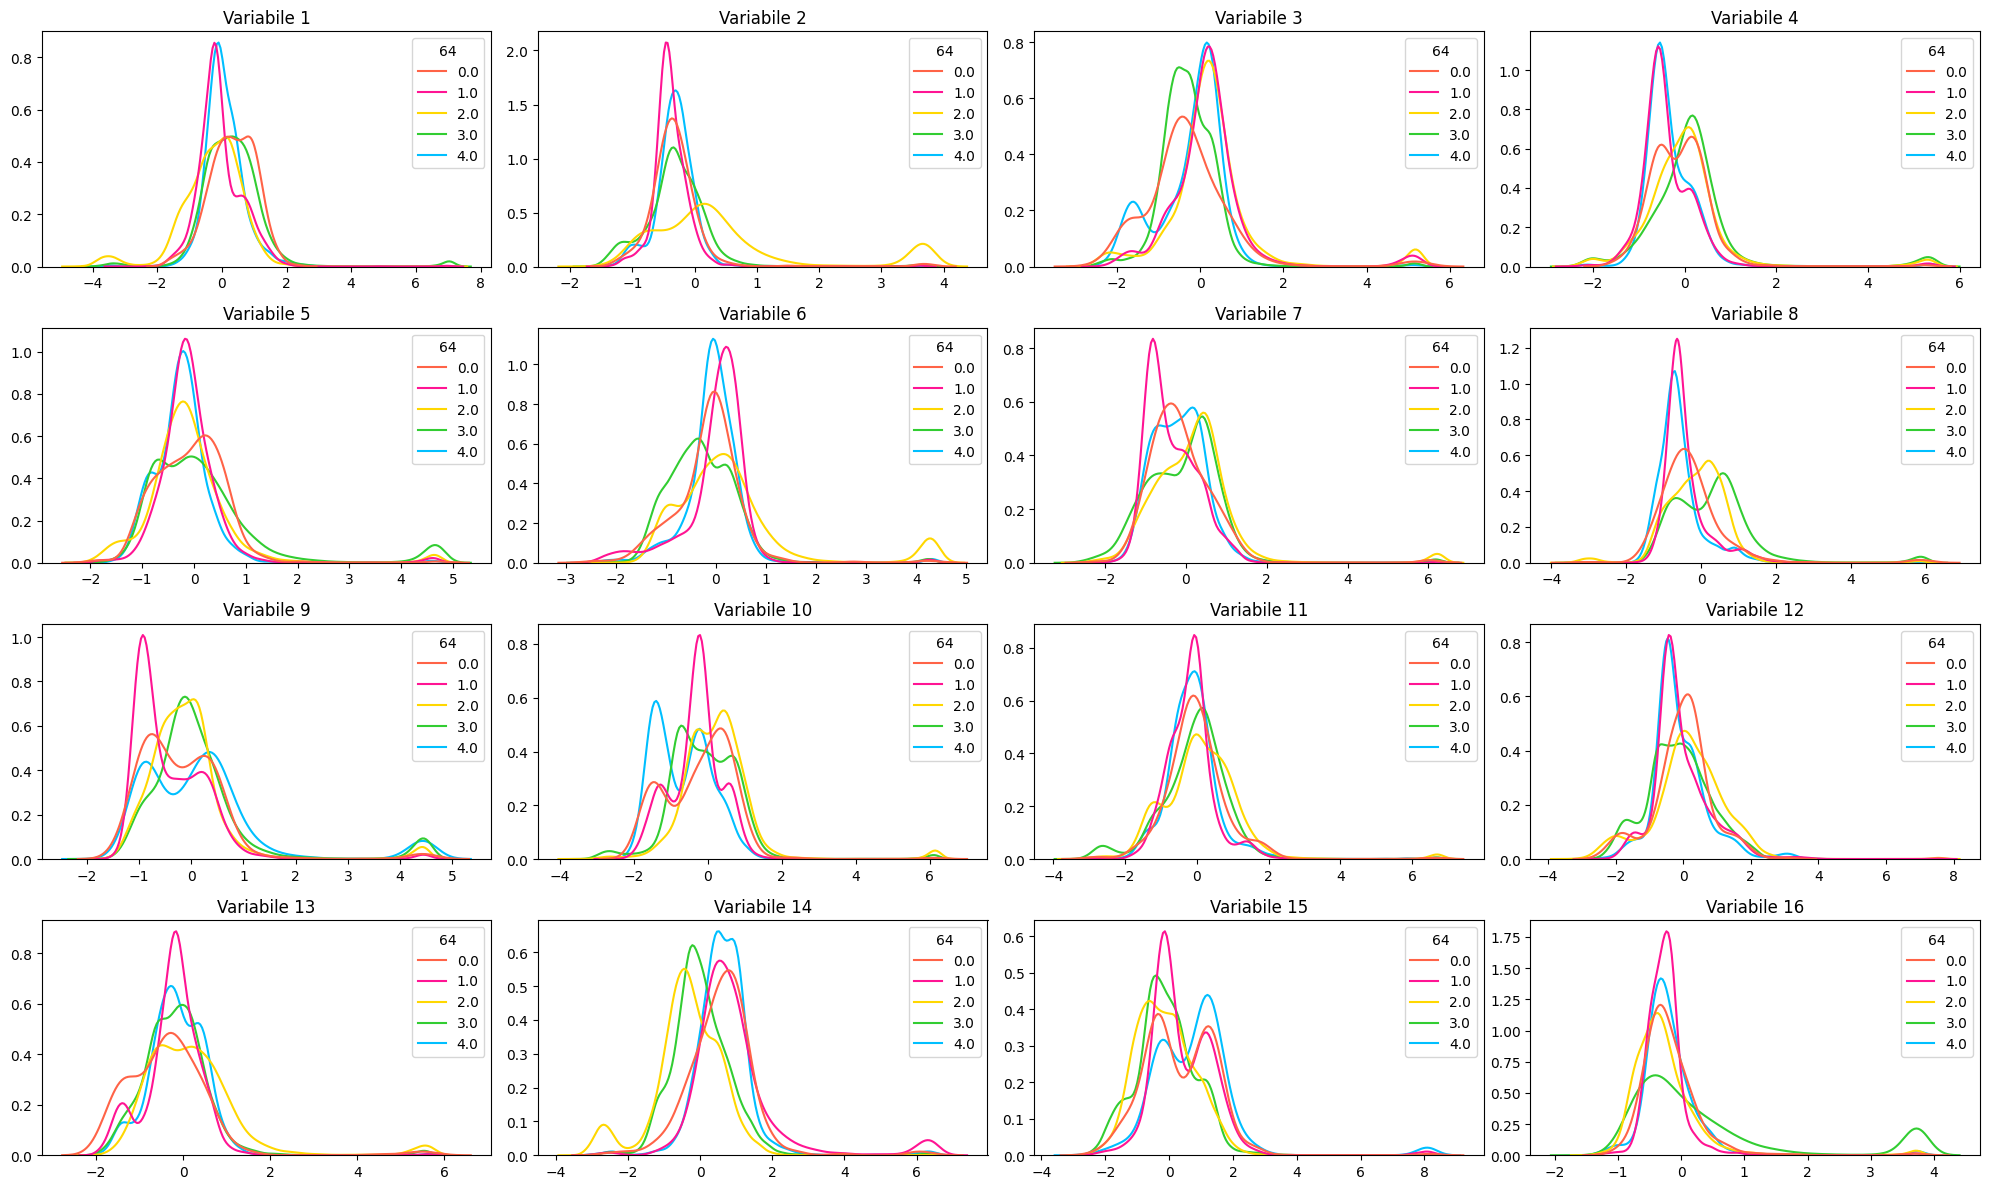

In [ ]:
 plt.figure(figsize=(20, 12))  # Regola la dimensione in base a 4 grafici per riga

for i in range(1, 17):
    plt.subplot(4, 4, i)  # Griglia 4x4: 4 grafici per riga
    sns.kdeplot(
        data=df_train_std,
        x=df_train_std[i],
        hue=df_train_std[64],
        fill=False,
        common_norm=False,
        palette=colori,
        linewidth=1.5
    )
    plt.title(f'Variabile {i}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

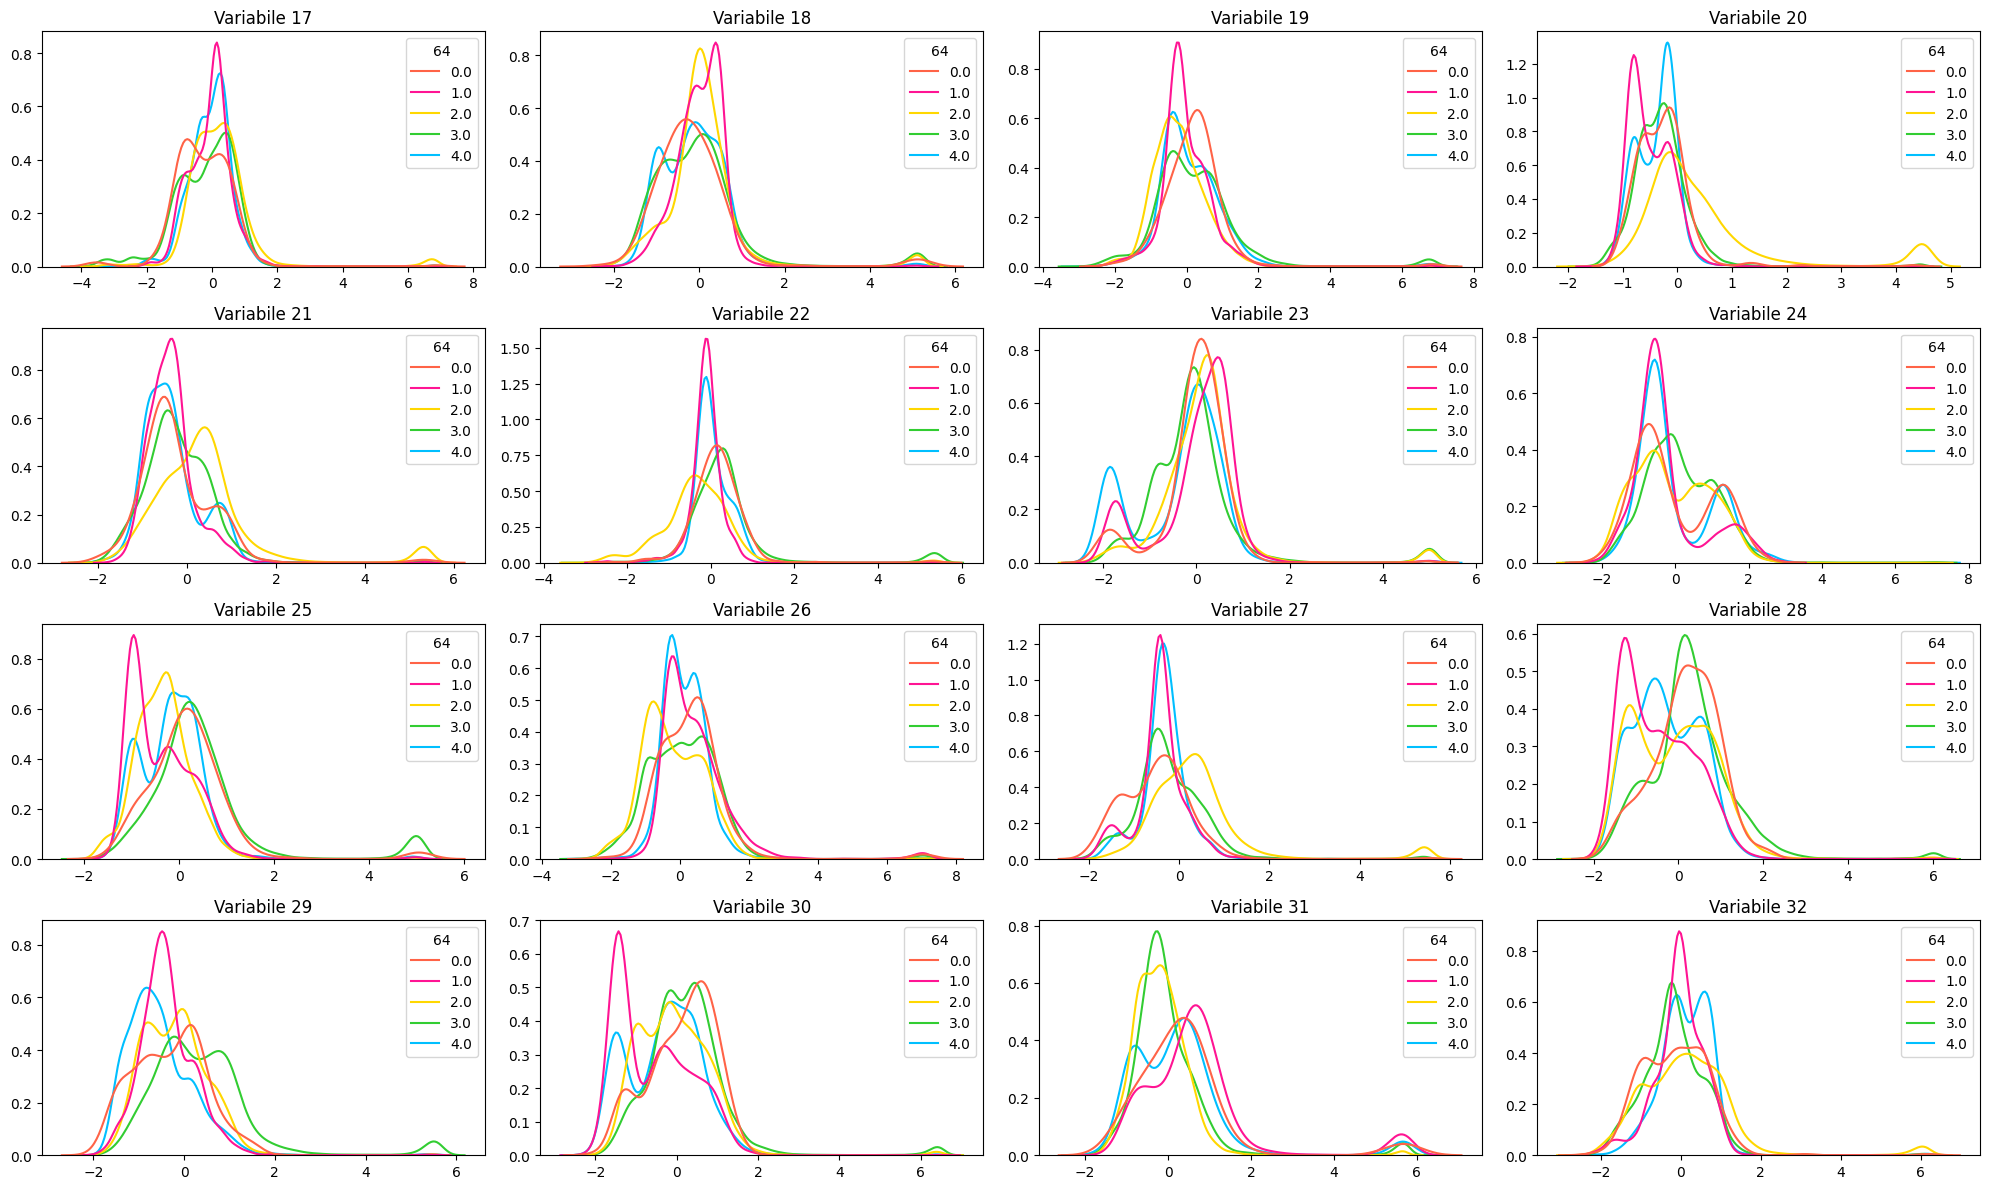

In [ ]:
plt.figure(figsize=(20, 12))  # Dimensione grande per 4x4 grafici

for i, col in enumerate(range(17, 33), start=1):
    plt.subplot(4, 4, i)  # 16 sottotrame in una griglia 4x4
    sns.kdeplot(
        data=df_train_std,
        x=df_train_std[col],
        hue=df_train_std[64],  # Variabile target o di classificazione
        fill=False,
        common_norm=False,
        palette=colori,
        linewidth=1.5
    )
    plt.title(f'Variabile {col}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

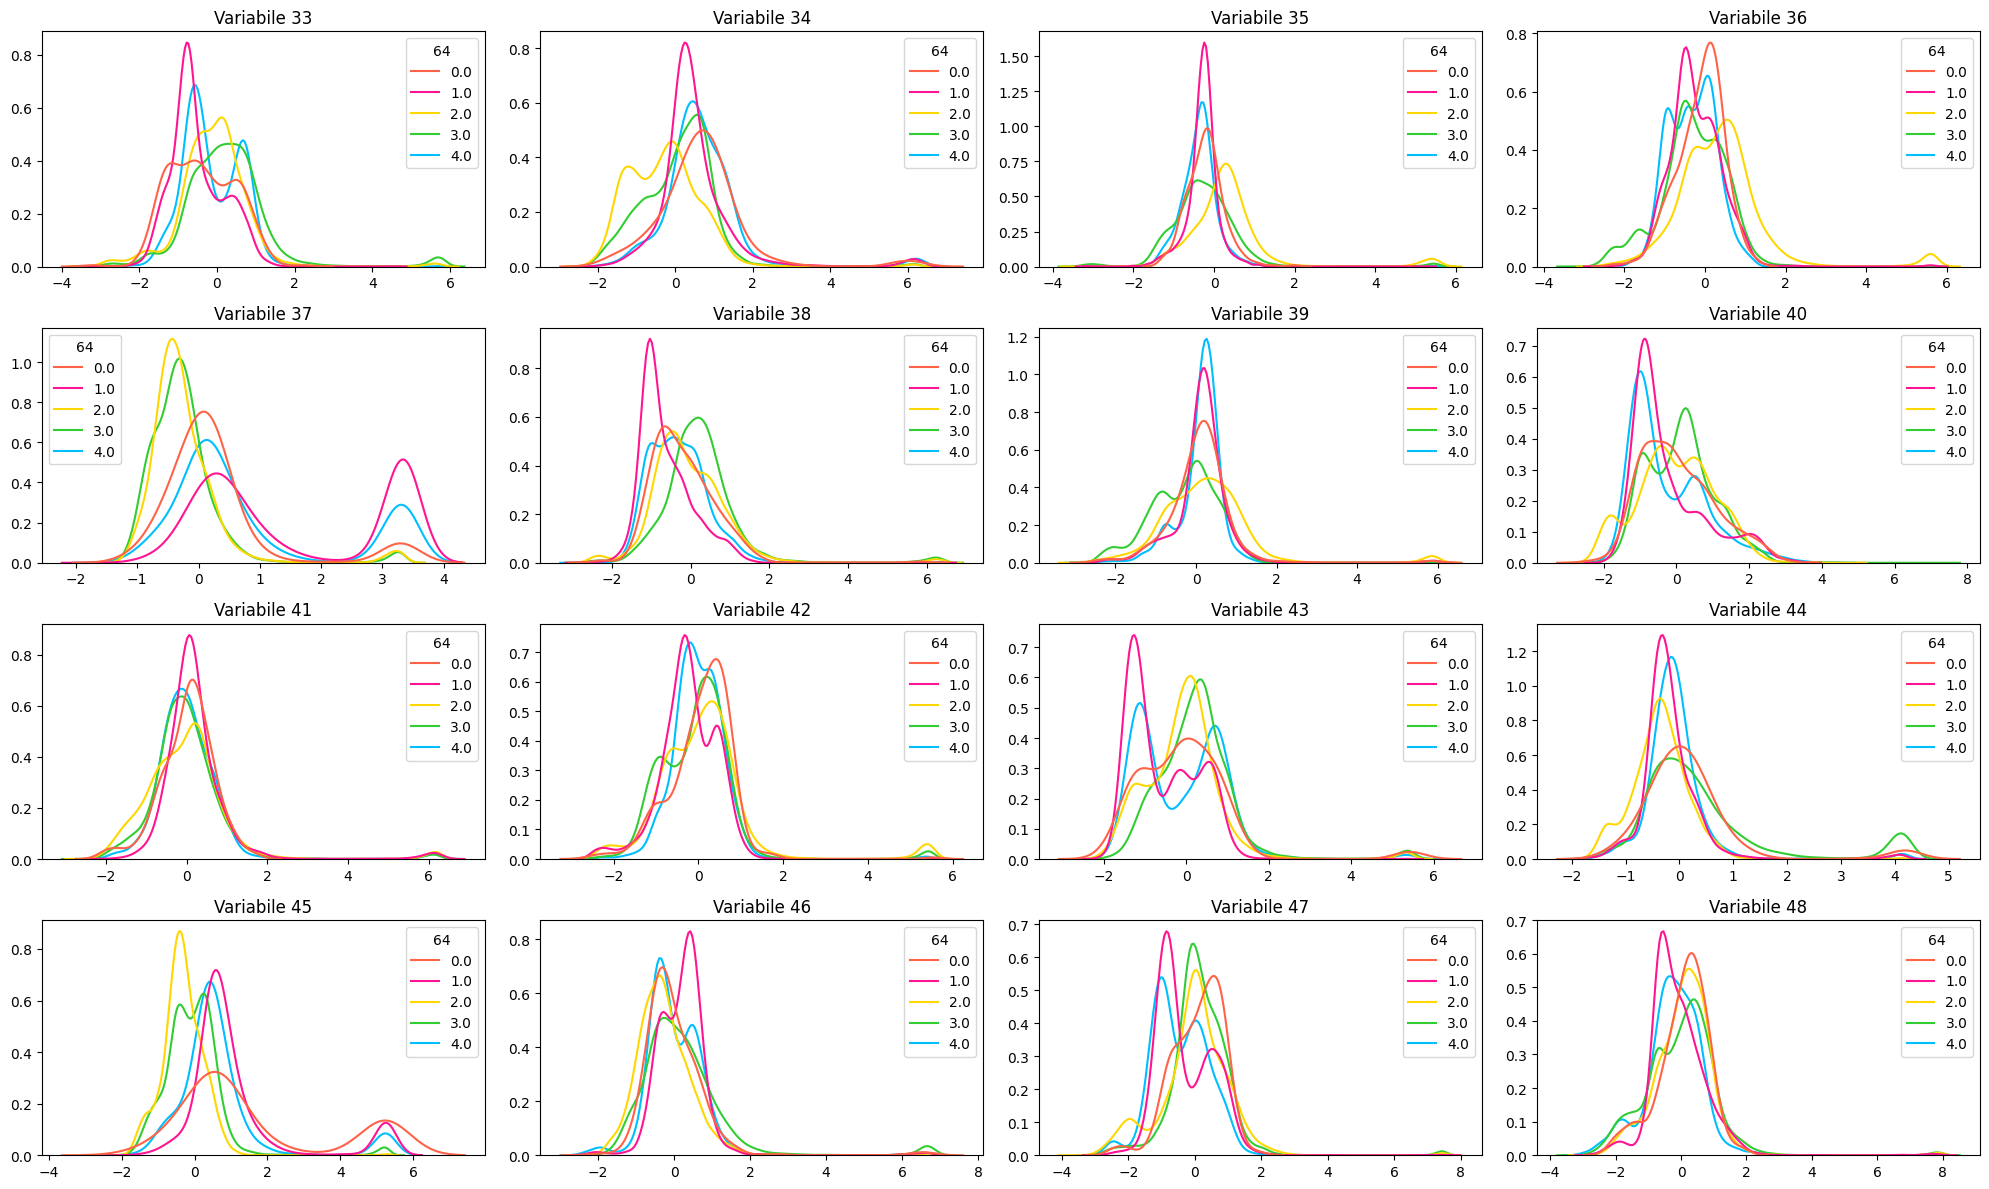

In [ ]:
plt.figure(figsize=(20, 12))  # 4 righe x 4 colonne

for i, col in enumerate(range(33, 49), start=1):
    plt.subplot(4, 4, i)
    sns.kdeplot(
        data=df_train_std,
        x=df_train_std[col],
        hue=df_train_std[64],  # Variabile target
        fill=False,
        common_norm=False,
        palette=colori,
        linewidth=1.5
    )
    plt.title(f'Variabile {col}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

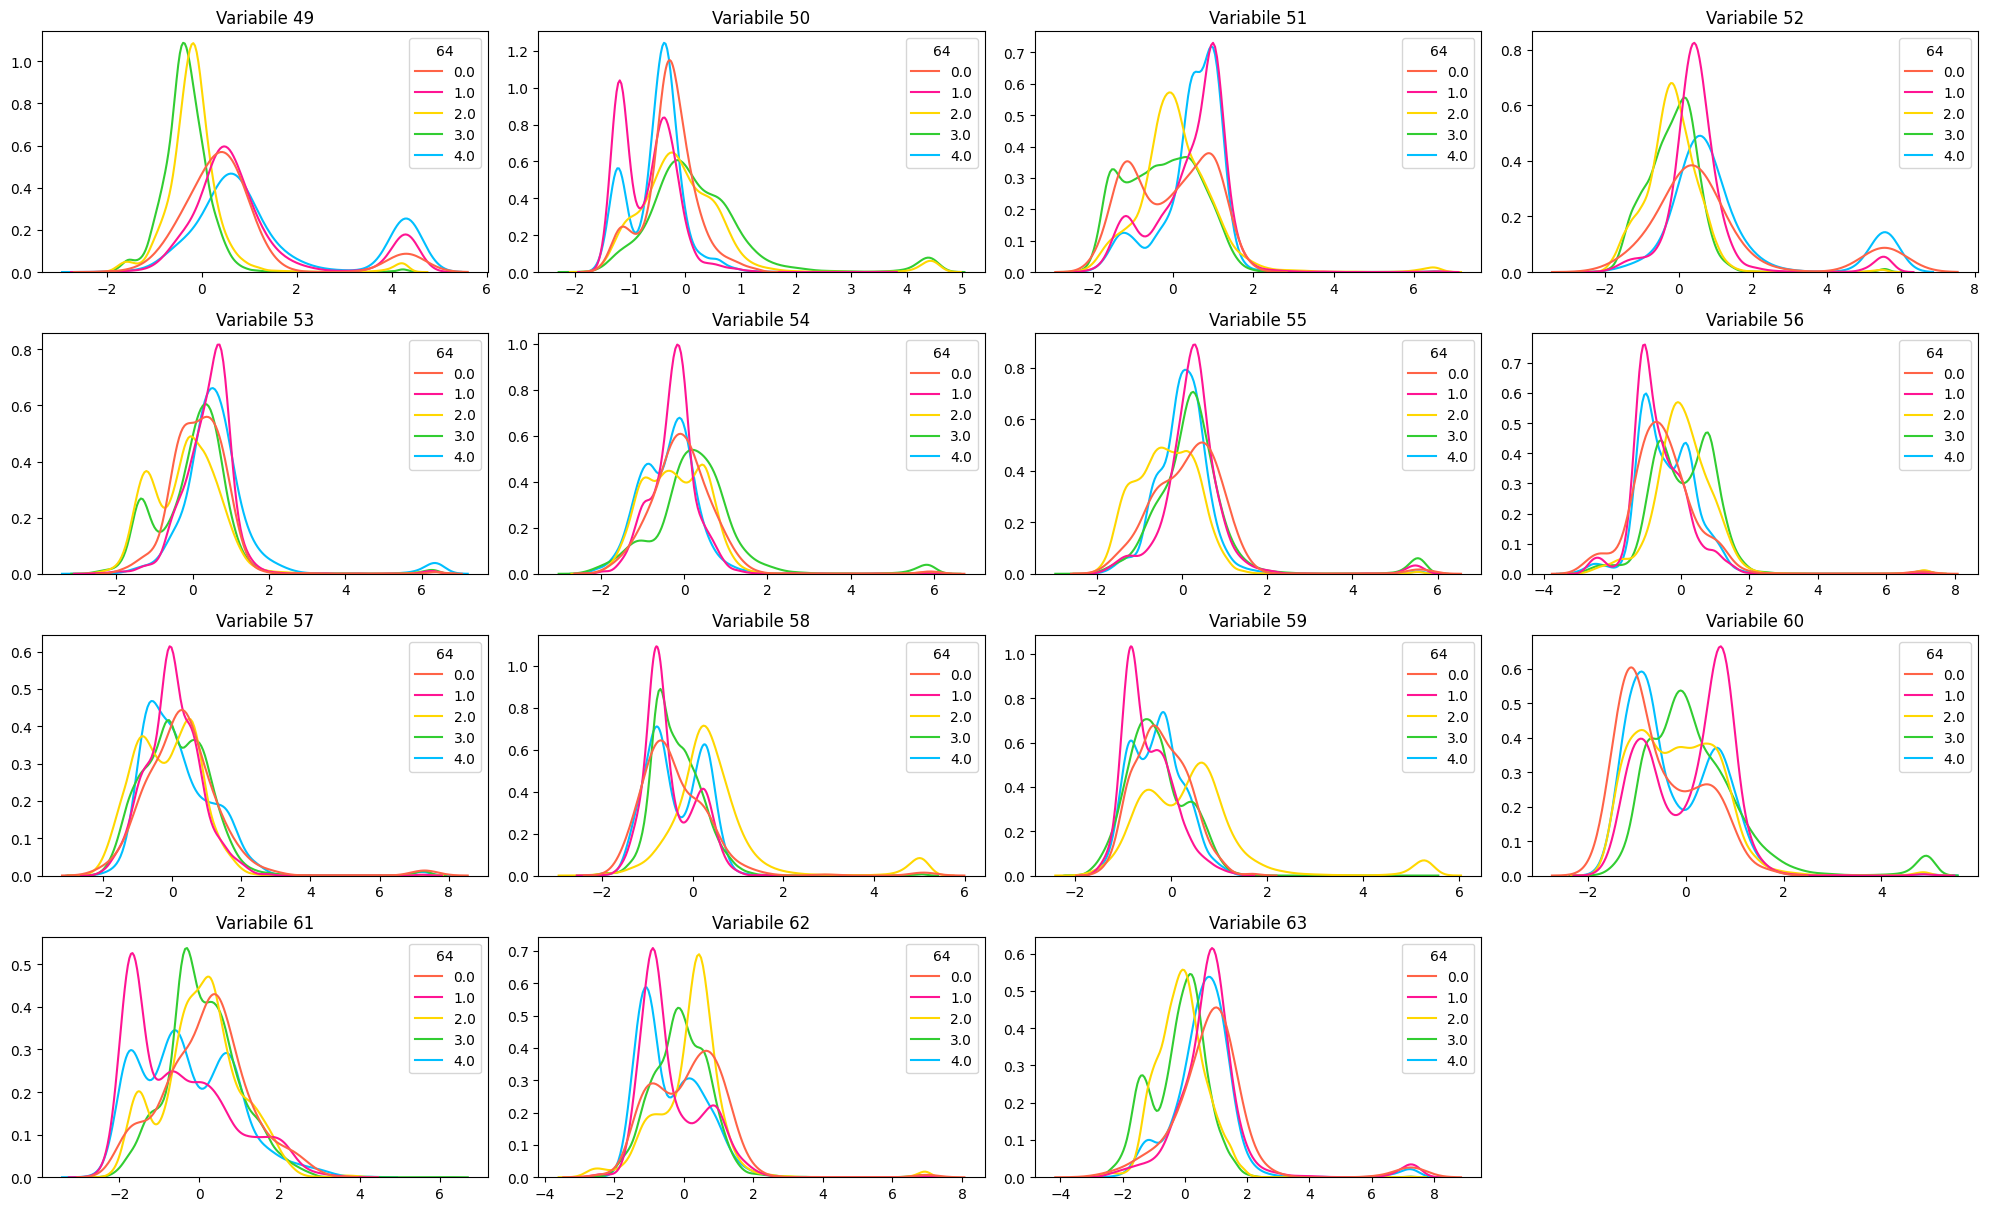

In [ ]:
plt.figure(figsize=(20, 15))  # Più altezza per 5 righe

for i, col in enumerate(range(49, 64), start=1):
    plt.subplot(5, 4, i)
    sns.kdeplot(
        data=df_train_std,
        x=df_train_std[col],
        hue=df_train_std[64],  # Etichetta/target
        fill=False,
        common_norm=False,
        palette=colori,
        linewidth=1.5
    )
    plt.title(f'Variabile {col}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

##Asimmetria
innanzitutto dividiamo le osservazioni del dataset in base alla classe di appartenenza;

successivamente con un ciclo di for vediamo quali sono le variabili asimmetriche e i pattern per le diverse classi.

In [ ]:
df_bas = df_train[df_train[64] == 0]
df_ebo = df_train[df_train[64] == 1]
df_eos = df_train[df_train[64] == 2]
df_lyt = df_train[df_train[64] == 3]
df_mon = df_train[df_train[64] == 4]

Per poter confrontare l'asimmetria tra le diverse classi ci conviene standardizzare i dataset così da essere sicuri che siano confrontabili

In [ ]:
from sklearn.preprocessing import StandardScaler

# Inizializza lo standardizzatore
scaler = StandardScaler()

# Applica la standardizzazione
s_df_bas = scaler.fit_transform(df_bas)
s_df_bas = pd.DataFrame(s_df_bas, columns=df_bas.columns)

s_df_ebo = scaler.fit_transform(df_ebo)
s_df_ebo = pd.DataFrame(s_df_ebo, columns=df_ebo.columns)

s_df_eos = scaler.fit_transform(df_eos)
s_df_eos = pd.DataFrame(s_df_eos, columns=df_eos.columns)

s_df_lyt = scaler.fit_transform(df_lyt)
s_df_lyt = pd.DataFrame(s_df_lyt, columns=df_lyt.columns)

s_df_mon = scaler.fit_transform(df_mon)
s_df_mon = pd.DataFrame(s_df_mon, columns=df_mon.columns)

#### Asimmetria cellule Basofile


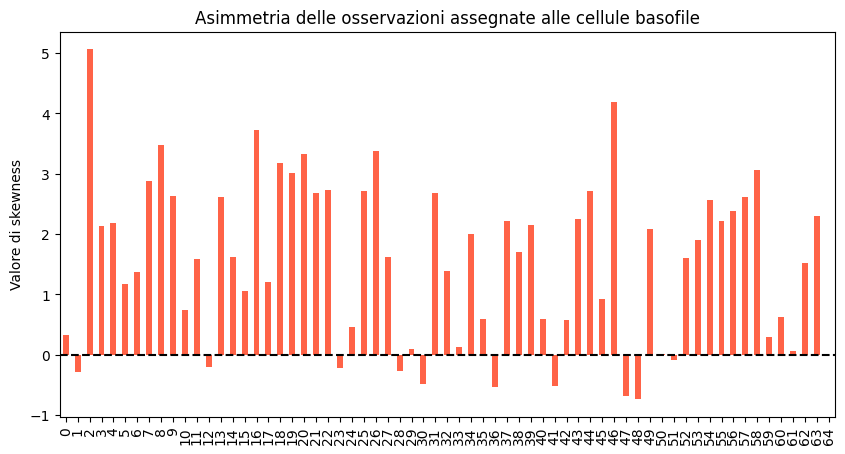

In [ ]:
plot_skewness(s_df_bas, "Asimmetria delle osservazioni assegnate alle cellule basofile", color="tomato")

####Asimmetria eritoblasti

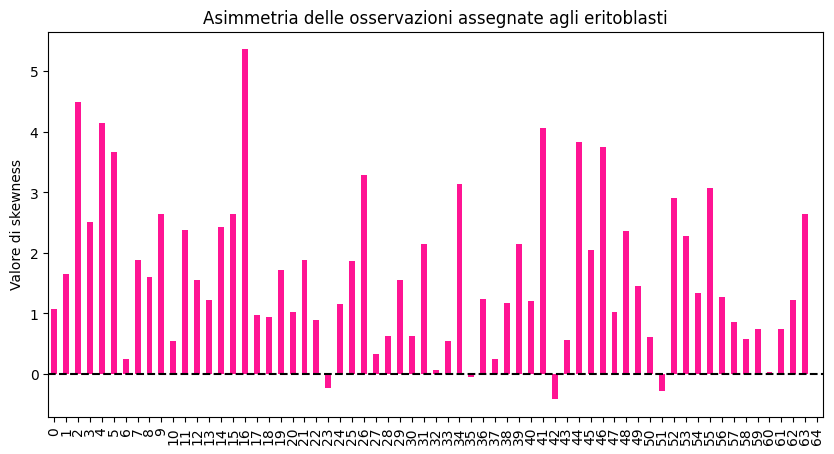

In [ ]:
plot_skewness(s_df_ebo, "Asimmetria delle osservazioni assegnate agli eritoblasti", color="deeppink")

####Asimmetria cellule eosinofile

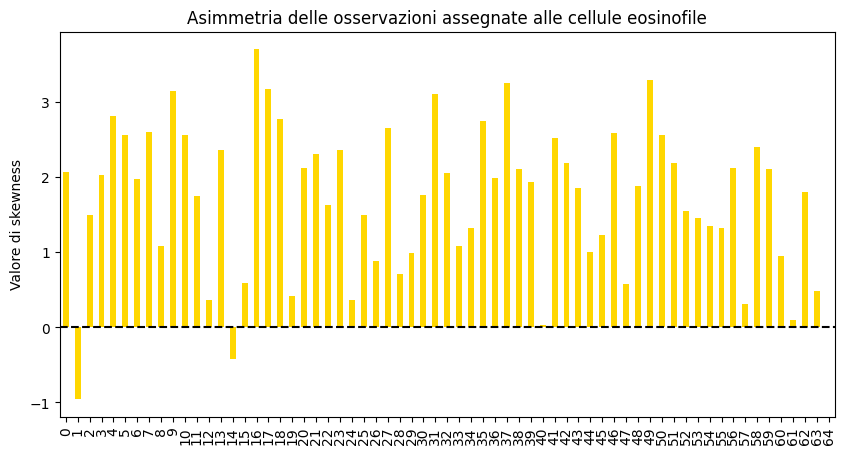

In [ ]:
plot_skewness(s_df_eos, "Asimmetria delle osservazioni assegnate alle cellule eosinofile", color="gold")

####Asimmetria linfociti

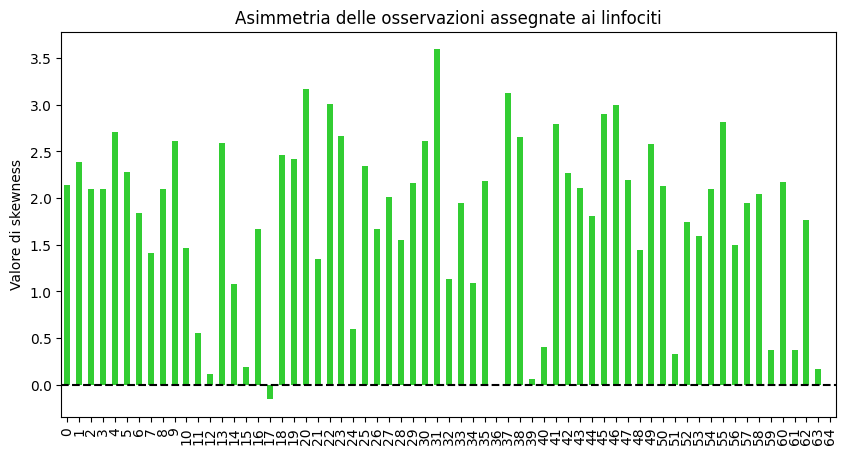

In [ ]:
plot_skewness(s_df_lyt, "Asimmetria delle osservazioni assegnate ai linfociti", color="limegreen")

####Asimmetria monociti

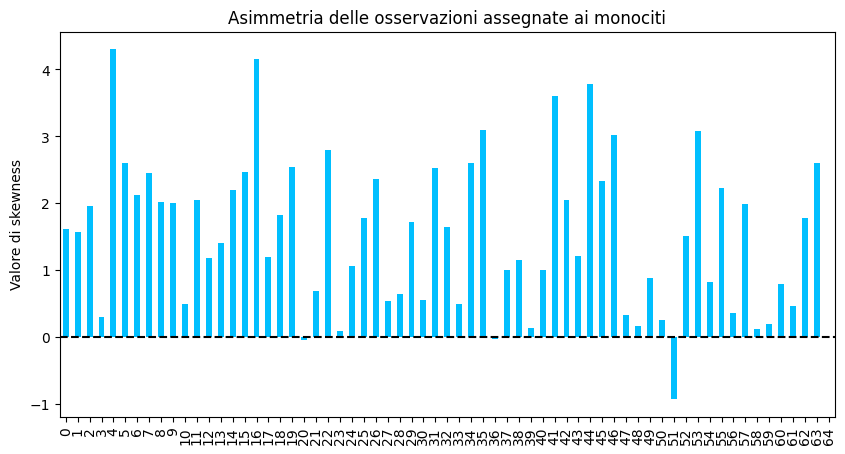

In [ ]:
plot_skewness(s_df_mon, "Asimmetria delle osservazioni assegnate ai monociti", color="deepskyblue")

Le variabili in cui è particolarmente accentuata la differenza della distribuzione per le classi è sicuramente la variabile 1, 4, 16, 51, osserviamo i boxplot di queste variabili condizionati sulle variabili per capirne di più

<ipython-input-31-43b6157f927a>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x=df_train[64], y=df_train[0], palette=colori)


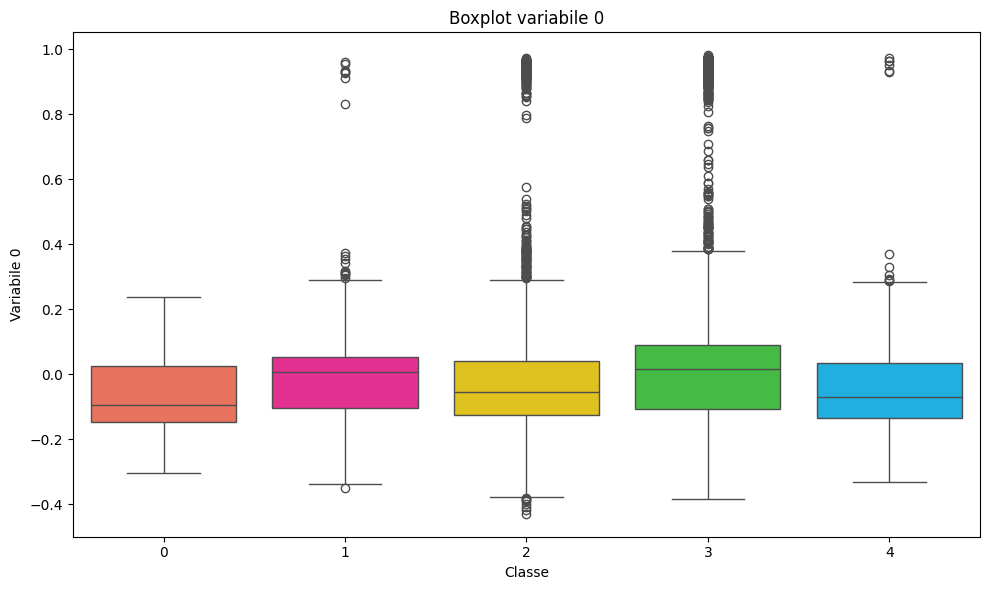

In [ ]:
plot_boxplot_by_class(df_train, 0, 64, colori)

<ipython-input-32-16f47ddfdf81>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x=df_train[64], y=df_train[1], palette=colori)


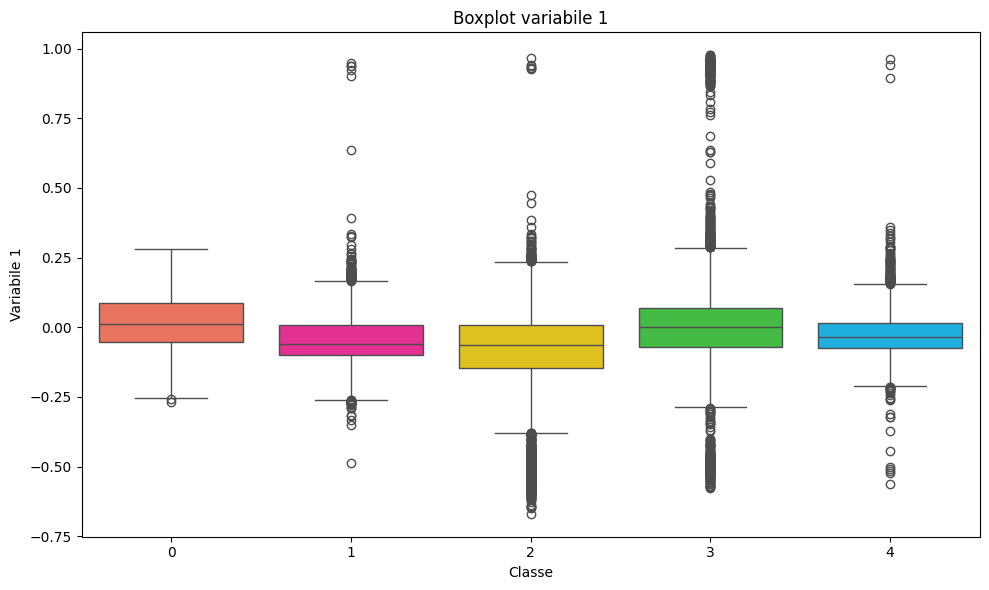

In [ ]:
plot_boxplot_by_class(df_train, 1, 64, colori)

<ipython-input-33-e2d58b8898e6>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x=df_train[64], y=df_train[4], palette=colori)


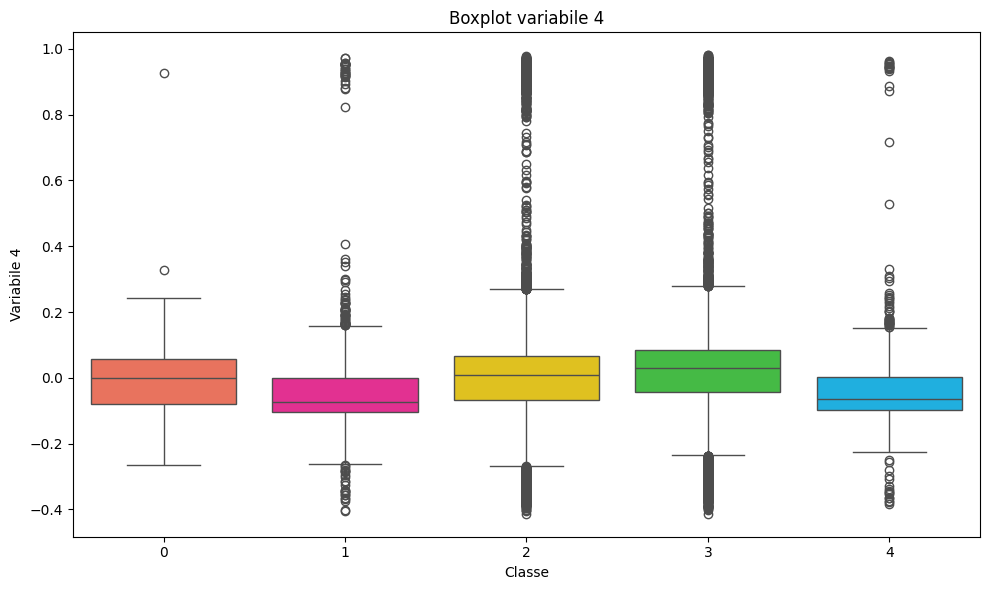

In [ ]:
plot_boxplot_by_class(df_train, 4, 64, colori)

<ipython-input-34-deda4b0bf260>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x=df_train[64], y=df_train[16], palette=colori)


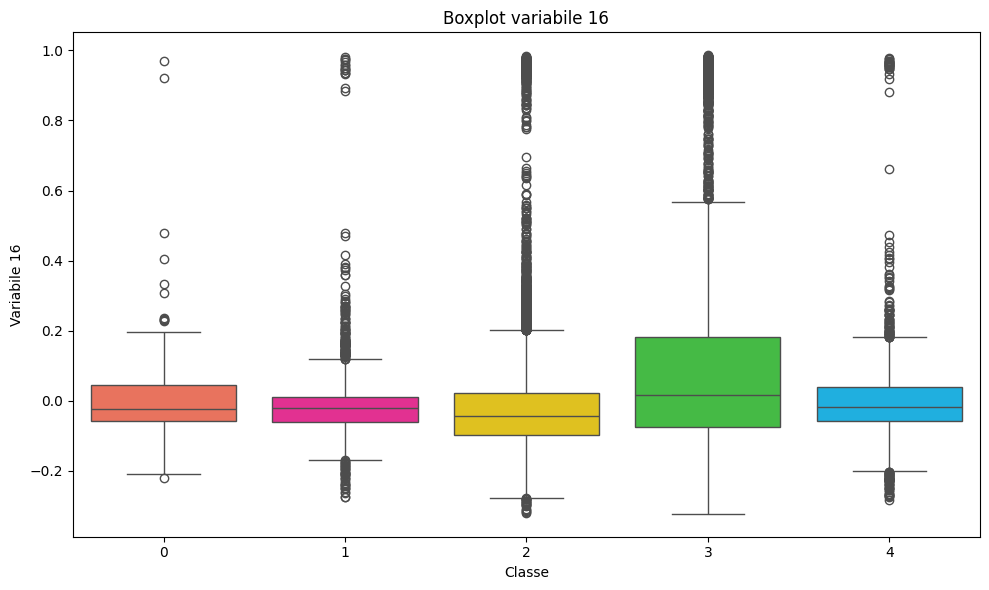

In [ ]:
plot_boxplot_by_class(df_train, 16, 64, colori)

<ipython-input-35-661c0ac184a6>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x=df_train[64], y=df_train[51], palette=colori)


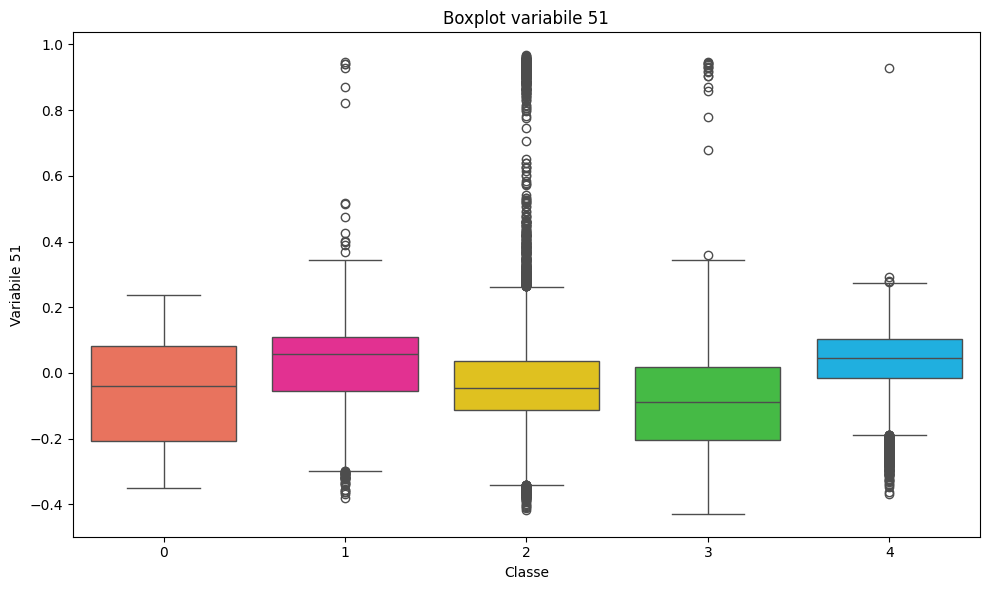

In [ ]:
plot_boxplot_by_class(df_train, 51, 64, colori)

<ipython-input-56-0ec107d9f310>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x=df_train[64], y=df_train[37], palette=colori)


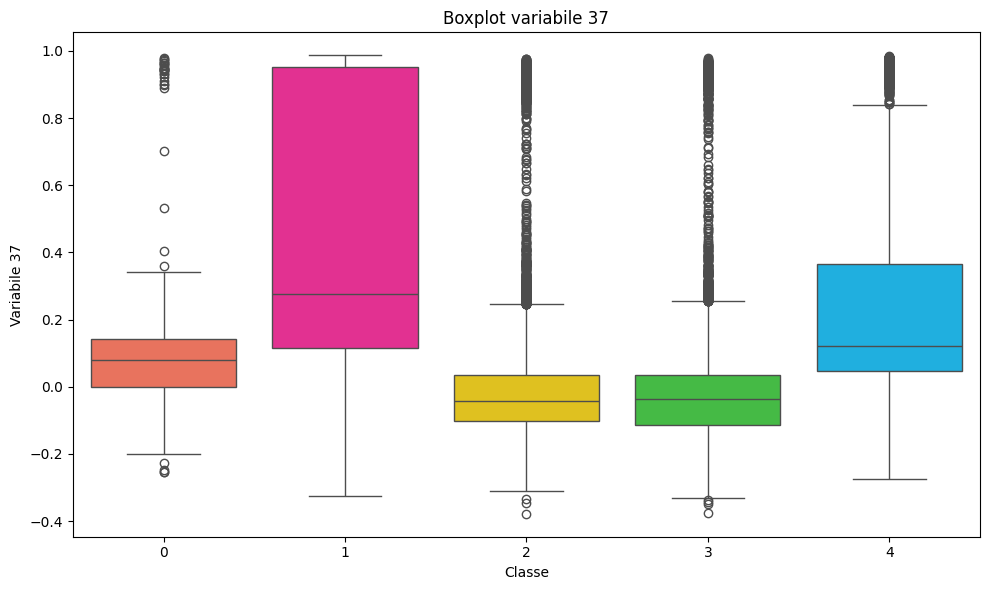

In [ ]:
plot_boxplot_by_class(df_train, 37, 64, colori)

<ipython-input-57-167d909986c2>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x=df_train[64], y=df_train[39], palette=colori)


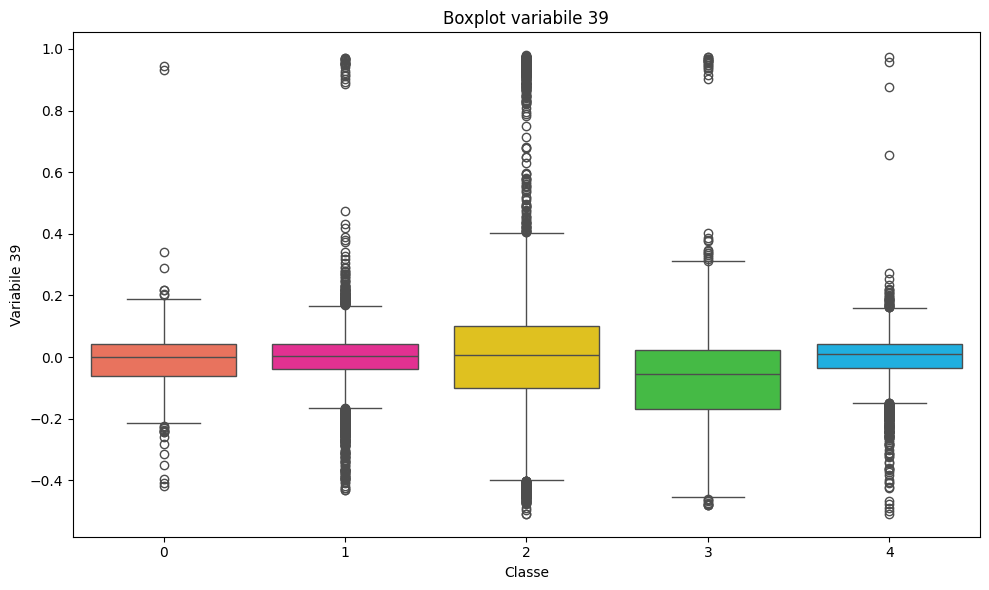

In [ ]:
plot_boxplot_by_class(df_train, 39, 64, colori)

<ipython-input-58-ed32938301a8>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x=df_train[64], y=df_train[60], palette=colori)


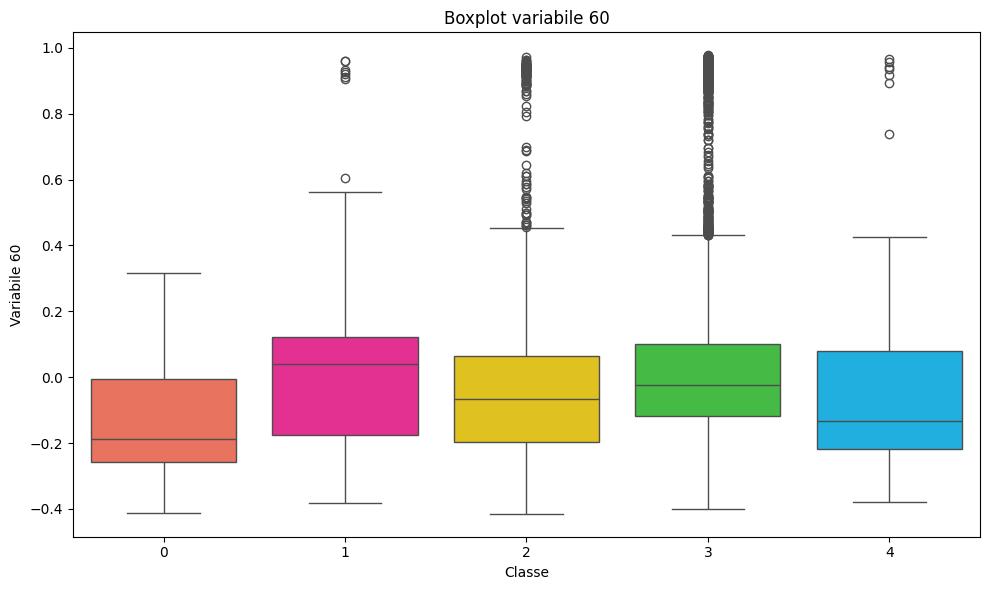

In [ ]:
plot_boxplot_by_class(df_train, 60, 64, colori)

<ipython-input-59-b71518c650d2>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x=df_train[64], y=df_train[61], palette=colori)


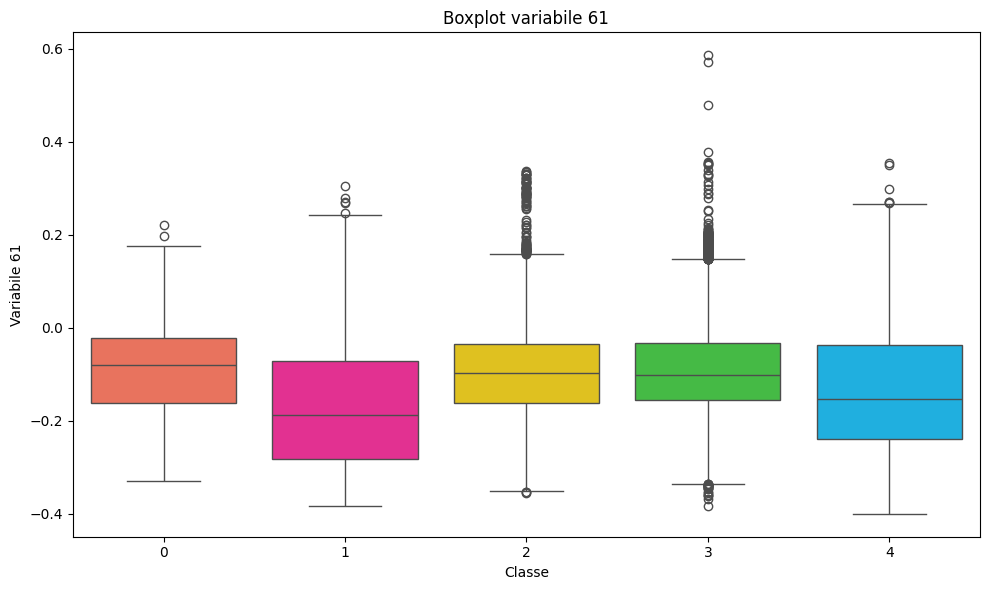

In [ ]:
plot_boxplot_by_class(df_train, 61, 64, colori)

## Correlazione tra le features

In [ ]:
# Matrice di correlazione
correlation_matrix = df_train.corr()

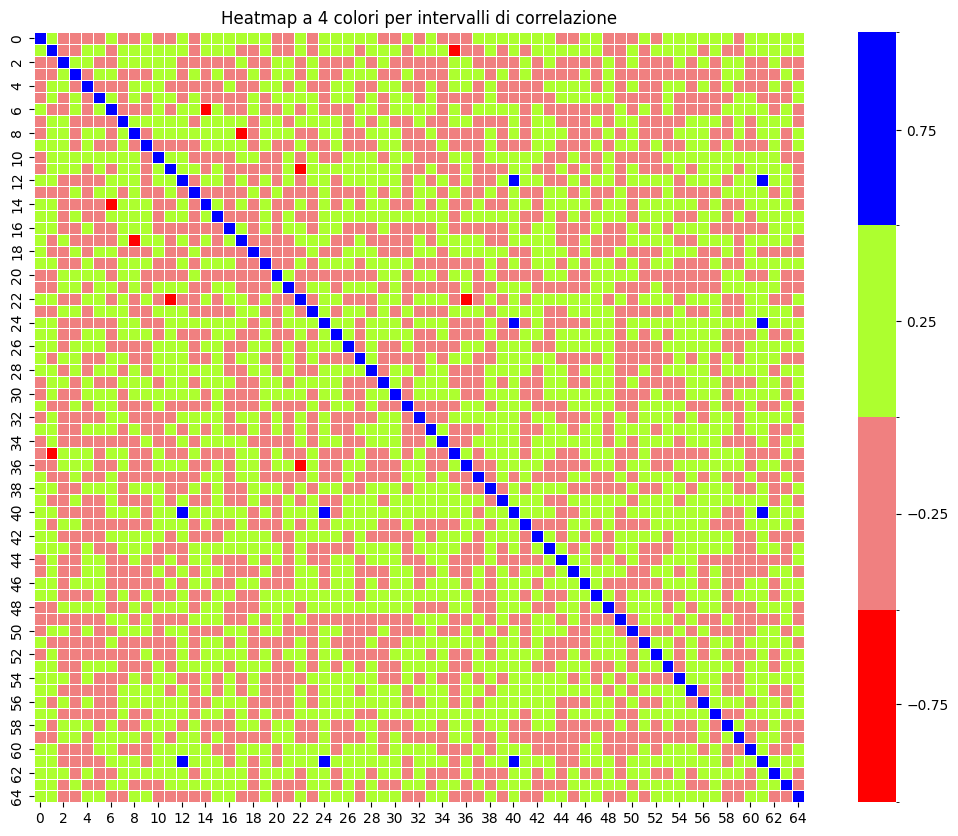

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
bounds = [-1.01, -0.5, 0, 0.5, 1.01]
colors = ['red', 'lightcoral', 'greenyellow', 'b']
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=False, cmap=cmap, norm=norm, square=True,linewidths=0.5, cbar_kws={"ticks": [-0.75, -0.25, 0.25, 0.75]})
plt.title("Heatmap a 4 colori per intervalli di correlazione")
plt.show()

Riorganizzo la heatmap mettendo le variabili più correlate vicine tra loro

La presenza di alta correlazione tra variabili indica che una delle due variabili è una trasformazione lineare dell'altra, per sfoltire il dataset possiamo quindi eliminare una delle due variabili linearmente dipendenti


In [ ]:
X_train_filtered, to_drop = remove_correlated_features(df_train.iloc[:, :-1], threshold=0.5)
df_filtered = df_train.drop(columns=to_drop)

Variabili eliminate perché correlate > ±0.5:
[14, 17, 22, 35, 36, 40, 61]
Nuova forma del dataset: (44800, 58)


##Studio di pattern e outliers


In [ ]:
# Calcolo dei quartili e dell'IQR per ogni variabile
Q1 = df_filtered.quantile(0.25)
Q3 = df_filtered.quantile(0.75)
IQR = Q3 - Q1

# Identificare gli outliers (valori che si trovano fuori dall'IQR)
outliers = ((df_filtered < (Q1 - 1.5 * IQR)) | (df_filtered > (Q3 + 1.5 * IQR)))

outliers_count = outliers.sum()

# Visualizzazione del numero di outliers per ogni variabile
print("Outliers per ogni variabile:")
print(outliers_count)

Outliers per ogni variabile:
0      704
1     1444
2     3035
3     2441
4     2141
5     2087
6     1849
7      647
8     1081
9     1909
10    1021
11    1441
12     746
13    1205
15     311
16    3630
18    1469
19    1068
20    2683
21    1088
23    3229
24      61
25    1280
26     315
27    1231
28     335
29     893
30     488
31    1214
32     644
33    1198
34     447
37    3638
38    1069
39    1018
41    1404
42    1315
43     756
44    2740
45    1265
46    1006
47    1656
48     679
49    3369
50    1651
51     350
52    1066
53     585
54     821
55     947
56     617
57     252
58    1281
59     979
60     762
62     578
63     550
64     309
dtype: int64


il nostro dataset presenta un altissimo numero di outliers, uno dei modi per gestirli è rimuoverli dal dataset, per fare ciò senza cambiare le dimensioni del dataset, potremmo sostituirli con la media o la mediana (preferibilmente la seconda perché è una misura robusta), alternativamente potremmo applicare delle trasformazioni come quella logaritmica per far si che la presenza degli outliers non influisca negativamente sull'analisi  

In [ ]:
df_log_transformed = df_filtered.copy()
df_log_transformed = np.log(df_log_transformed + 1)
df_log_transformed.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,62,63,64
0,-0.119010,-0.054568,-0.097332,0.036019,0.346497,-0.151244,-0.054236,-0.080079,0.000497,0.136380,...,-0.000295,0.017502,0.046177,-0.206197,-0.105118,-0.133120,-0.211410,0.003889,-0.001090,1.386719
1,0.039135,-0.009162,-0.111666,-0.079679,0.188651,0.024587,0.047534,-0.434331,0.194317,0.053406,...,-0.035174,-0.125837,-0.170895,0.026036,0.165724,-0.092858,-0.072165,-0.313737,0.060737,1.098633
2,0.165201,-0.022516,0.057806,0.070118,-0.008410,-0.015342,-0.065418,0.000972,-0.216303,0.670821,...,-0.236865,0.022619,-0.066318,-0.140166,0.058653,-0.082046,0.005767,-0.076690,-0.243823,1.609375
3,0.050536,-0.073509,-0.147258,0.033698,0.265004,0.053476,0.314294,-0.514123,-0.018202,0.012532,...,-0.111830,-0.324086,-0.146035,0.002559,0.382448,-0.081133,-0.047882,-0.193003,0.096069,1.098633
4,-0.330416,-0.030484,0.074713,-0.030581,0.103211,0.285389,-0.222645,-0.099120,0.149546,-0.010149,...,0.059985,-0.101767,-0.120730,-0.269988,-0.112061,-0.086768,-0.049544,-0.119195,-0.281341,1.386719


#Selezione variabili rilevanti (PCA)
Per comprendere quanti sono le componenti principali rilevanti in questo dataset utilizziamo lo screeplot, che ci esplicità la varianza spiegata da ogni componente **principale**

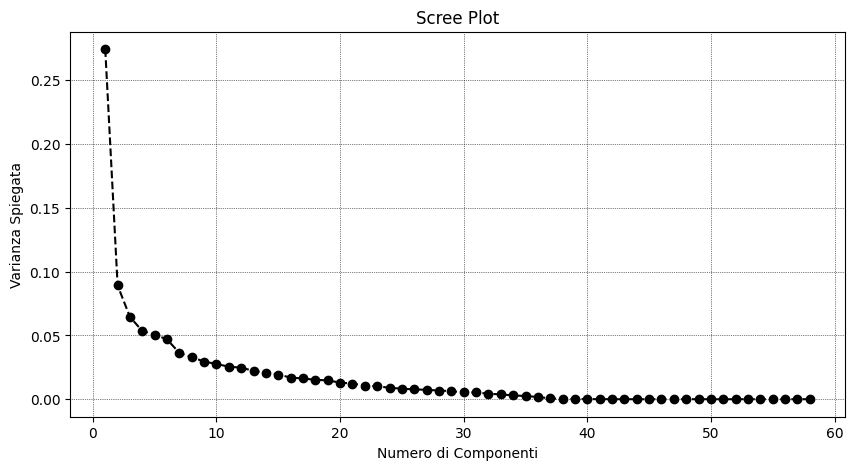

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Applichiamo PCA
pca = PCA()
pca.fit(df_filtered)

# Calcoliamo la varianza spiegata
explained_variance = pca.explained_variance_ratio_

# Creiamo lo scree plot in nero
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='black')
plt.xlabel("Numero di Componenti", color='black')
plt.ylabel("Varianza Spiegata", color='black')
plt.title("Scree Plot", color='black')
plt.xticks(color='black')
plt.yticks(color='black')
plt.grid(color='black', linestyle=':', linewidth=0.5)
plt.show()


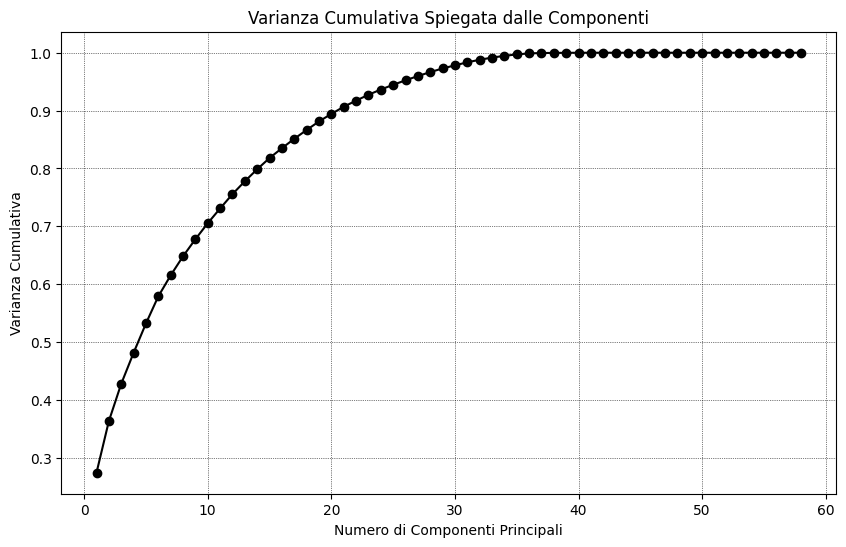

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calcolo varianza cumulativa
cumulative_variance = np.cumsum(explained_variance)

# Grafico in nero
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='black')
plt.xlabel("Numero di Componenti Principali", color='black')
plt.ylabel("Varianza Cumulativa", color='black')
plt.title("Varianza Cumulativa Spiegata dalle Componenti", color='black')
plt.xticks(color='black')
plt.yticks(color='black')
plt.grid(True, color='black', linestyle=':', linewidth=0.5)
plt.show()


In [ ]:
# Stampiamo l'indice, la varianza spiegata e quella cumulativa
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"Componente {i + 1}: {var:.4f} ({var * 100:.2f}%) - Varianza Cumulativa: {cum_var:.4f} ({cum_var * 100:.2f}%)")

Componente 1: 0.2744 (27.44%) - Varianza Cumulativa: 0.2744 (27.44%)
Componente 2: 0.0892 (8.92%) - Varianza Cumulativa: 0.3636 (36.36%)
Componente 3: 0.0645 (6.45%) - Varianza Cumulativa: 0.4280 (42.80%)
Componente 4: 0.0535 (5.35%) - Varianza Cumulativa: 0.4815 (48.15%)
Componente 5: 0.0507 (5.07%) - Varianza Cumulativa: 0.5322 (53.22%)
Componente 6: 0.0469 (4.69%) - Varianza Cumulativa: 0.5791 (57.91%)
Componente 7: 0.0363 (3.63%) - Varianza Cumulativa: 0.6153 (61.53%)
Componente 8: 0.0329 (3.29%) - Varianza Cumulativa: 0.6483 (64.83%)
Componente 9: 0.0295 (2.95%) - Varianza Cumulativa: 0.6778 (67.78%)
Componente 10: 0.0276 (2.76%) - Varianza Cumulativa: 0.7054 (70.54%)
Componente 11: 0.0255 (2.55%) - Varianza Cumulativa: 0.7309 (73.09%)
Componente 12: 0.0248 (2.48%) - Varianza Cumulativa: 0.7557 (75.57%)
Componente 13: 0.0222 (2.22%) - Varianza Cumulativa: 0.7779 (77.79%)
Componente 14: 0.0208 (2.08%) - Varianza Cumulativa: 0.7987 (79.87%)
Componente 15: 0.0194 (1.94%) - Varianza C

##Riduzione della dimensionalità
Attraverso lo studio delle PCA e il relativo screeplot, ho notato che il flesso si ha circa intorno alle prime 30 componenti principali, quindi attraverso lo studio dei loadings estraggo dal dataset le 30 variabili più importanti così da rendere più facile il problema di classificazione

In [ ]:
df_ridotto = seleziona_variabili_pca(df_filtered)

In [ ]:
df_ridotto2 = seleziona_variabili_pca(df_filtered, 20, 20)

In [ ]:
column_names = df_ridotto.columns.tolist()
column_names


[56,
 15,
 21,
 30,
 31,
 53,
 32,
 48,
 45,
 50,
 51,
 55,
 11,
 26,
 1,
 19,
 0,
 20,
 7,
 39,
 62,
 41,
 27,
 13,
 4,
 47,
 25,
 59,
 46,
 33,
 64]

In [ ]:
df_ridotto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44800 entries, 0 to 44799
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   56      44800 non-null  float64
 1   15      44800 non-null  float64
 2   21      44800 non-null  float64
 3   30      44800 non-null  float64
 4   31      44800 non-null  float64
 5   53      44800 non-null  float64
 6   32      44800 non-null  float64
 7   48      44800 non-null  float64
 8   45      44800 non-null  float64
 9   50      44800 non-null  float64
 10  51      44800 non-null  float64
 11  55      44800 non-null  float64
 12  11      44800 non-null  float64
 13  26      44800 non-null  float64
 14  1       44800 non-null  float64
 15  19      44800 non-null  float64
 16  0       44800 non-null  float64
 17  20      44800 non-null  float64
 18  7       44800 non-null  float64
 19  39      44800 non-null  float64
 20  62      44800 non-null  float64
 21  41      44800 non-null  float64
 22

In [ ]:
df_ridotto.columns = list(range(31))


In [ ]:
df_ridotto.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,0.047259,-0.170009,-0.040289,-0.087082,-0.092378,-0.107914,-0.066227,-0.126320,-0.056494,0.231484,...,-0.069186,-0.053238,-0.067333,0.414105,-0.167304,0.205760,-0.124640,-0.143569,-0.123484,3
1,-0.157090,0.090553,-0.103786,0.178134,-0.040832,0.015898,0.212256,-0.094222,-0.181823,0.004812,...,-0.249933,-0.083019,0.209516,0.207619,-0.257152,0.110143,-0.088677,-0.065002,0.007256,2
2,-0.064166,-0.020551,-0.074724,0.010258,0.017079,0.112405,-0.075988,-0.274989,-0.192730,-0.066715,...,0.000068,-0.048014,-0.121717,-0.008375,-0.087846,-0.031263,-0.078771,0.017422,-0.128903,4
3,-0.135872,-0.022933,-0.014056,0.204693,-0.013344,0.016394,0.167845,0.042408,-0.163847,-0.006992,...,-0.243174,0.029665,0.141552,0.303436,-0.262623,0.038673,-0.077928,-0.066430,0.103038,2
4,-0.113727,-0.269842,-0.138465,0.114135,-0.140246,-0.020586,-0.098125,0.015632,0.011735,0.081628,...,-0.036394,-0.067259,0.039867,0.108725,-0.080712,-0.054675,-0.083110,0.042036,0.040476,3


In [ ]:
df_ridotto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44800 entries, 0 to 44799
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       44800 non-null  float64
 1   1       44800 non-null  float64
 2   2       44800 non-null  float64
 3   3       44800 non-null  float64
 4   4       44800 non-null  float64
 5   5       44800 non-null  float64
 6   6       44800 non-null  float64
 7   7       44800 non-null  float64
 8   8       44800 non-null  float64
 9   9       44800 non-null  float64
 10  10      44800 non-null  float64
 11  11      44800 non-null  float64
 12  12      44800 non-null  float64
 13  13      44800 non-null  float64
 14  14      44800 non-null  float64
 15  15      44800 non-null  float64
 16  16      44800 non-null  float64
 17  17      44800 non-null  float64
 18  18      44800 non-null  float64
 19  19      44800 non-null  float64
 20  20      44800 non-null  float64
 21  21      44800 non-null  float64
 22

#Visualizzazione 2D/3D
Per avere una visualizzazione chiara e utile all'analisi innanzitutto usiamo il dataset ripulito dalle variabili collineari e dalle variabili non significative. Inoltre, per avere una visualizzazione più chiara della separazione tra classi, non utilizziamo tutte e 44800 osservazioni ma estraiamo un campione casuale di 1000 osservazioni che dovrebbe rispecchiare la struttura dell'intero dataset.

In [ ]:
sample_1 = df_ridotto.sample(n=10000, random_state=42)

In [ ]:
sample = sample_1.copy()

# Applichiamo la trasformazione logaritmica a tutte le colonne tranne l'ultima
sample.iloc[:, :-1] = np.log(sample.iloc[:, :-1] + 1)

sample.head()


,56,15,21,30,31,53,32,48,45,50,...,41,27,13,4,47,25,59,46,33,64
14812,-0.117868,-0.078998,-0.051213,0.076634,-0.059122,0.054381,0.198732,-0.177698,0.061405,-0.051253,...,0.040232,0.028856,0.029336,-0.091807,-0.171660,-0.245820,0.166794,-0.118157,0.038938,2
21990,-0.010756,-0.140227,-0.005681,-0.178886,-0.085771,-0.316249,-0.216567,0.072428,-0.043245,0.257375,...,0.031909,0.110866,-0.158096,0.069883,-0.041911,0.012240,0.196363,-0.165626,-0.193924,2
3581,0.084160,-0.029283,-0.119677,-0.019589,0.083567,0.006237,-0.139783,-0.062856,-0.145734,-0.041614,...,0.131207,0.073850,-0.077671,-0.179053,-0.011744,0.022145,0.000468,0.110145,0.172158,2
32432,-0.080885,-0.049277,0.023122,0.097549,0.082785,-0.056801,0.211376,-0.147572,-0.029121,0.081222,...,0.002240,0.020154,0.203997,-0.039796,-0.029186,-0.178661,0.195728,-0.139624,0.053741,2
43126,0.005202,-0.142736,-0.146990,-0.176145,-0.150451,-0.098219,0.044295,-0.052131,0.038849,0.028577,...,-0.174885,0.083877,-0.289250,0.022249,0.015865,0.153981,-0.181364,-0.188811,-0.071793,3


## Visualizzazione 2D delle osservazioni usando le prime due PCA

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA con 30 componenti
pca = PCA(n_components=30)
X_pca = pca.fit_transform(sample.iloc[:, :-1])

# Etichette di classe
labels = sample.iloc[:, 30]

# Mappa esplicita classe → colore
color_map = {
    0: 'tomato',
    1: 'deeppink',
    2: 'gold',
    3: 'limegreen',
    4: 'deepskyblue',
}

# Grafico
plt.figure(figsize=(10, 7))
for label in sorted(labels.unique()):
    indices = labels == label
    plt.scatter(
        X_pca[indices, 0],  # PC1
        X_pca[indices, 1],  # PC2
        label=str(label),
        color=color_map[label],
        alpha=0.5,
        s=50
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualizzazione 2D delle prime 30 Componenti Principali')
plt.legend(title='Classe')
plt.grid(True)
plt.tight_layout()
plt.show()


##Visualizzazione 3D sulle prime 3 PCA

##Grafico interattivo con plotly

In [ ]:
embedding_3d = pca.fit_transform(sample.iloc[:, :-1])
y = sample.iloc[:, 30]

unique_labels = sorted(y.unique())
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}


data = []
for label in unique_labels:
    indices = y == label
    scatter = go.Scatter3d(
        x=embedding_3d[indices, 0],
        y=embedding_3d[indices, 1],
        z=embedding_3d[indices, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=color_map[label],
            opacity=0.6,
            line=dict(width=0)
        ),
        name=f"Classe {label}",
        text=[f"Classe: {label}"] * sum(indices),
        hoverinfo='text'
    )
    data.append(scatter)


layout = go.Layout(
    title="Visualizzazione 3D PCA (Colorata per Classe)",
    scene=dict(
        xaxis_title='PCA Component 1',
        yaxis_title='PCA Component 2',
        zaxis_title='PCA Component 3'
    ),
    legend=dict(itemsizing='constant'),
    margin=dict(l=0, r=0, b=0, t=40)
)


fig = go.Figure(data=data, layout=layout)
fig.show()

In [ ]:
from google.colab import drive
import plotly.graph_objects as go

# Monta Google Drive
drive.mount('/content/drive')

# Genera il grafico come hai fatto prima
embedding_3d = pca.fit_transform(sample.iloc[:, :-1])
y = sample.iloc[:, 30]

unique_labels = sorted(y.unique())
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}

data = []
for label in unique_labels:
    indices = y == label
    scatter = go.Scatter3d(
        x=embedding_3d[indices, 0],
        y=embedding_3d[indices, 1],
        z=embedding_3d[indices, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=color_map[label],
            opacity=0.6,
            line=dict(width=0)
        ),
        name=f"Classe {label}",
        text=[f"Classe: {label}"] * sum(indices),
        hoverinfo='text'
    )
    data.append(scatter)

layout = go.Layout(
    title="Visualizzazione 3D PCA (Colorata per Classe)",
    scene=dict(
        xaxis_title='PCA Component 1',
        yaxis_title='PCA Component 2',
        zaxis_title='PCA Component 3'
    ),
    legend=dict(itemsizing='constant'),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Crea la figura
fig = go.Figure(data=data, layout=layout)

# Specifica il percorso nel tuo Google Drive
file_path = '/content/drive/My Drive/grafico_interattivo_pca.html'

# Salva il grafico interattivo nel Google Drive
fig.write_html(file_path)

# Conferma il salvataggio
print(f"Grafico salvato in: {file_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Grafico salvato in: /content/drive/My Drive/grafico_interattivo_pca.html


##Confronto visualizzazione 2D UMAP e t-SNE

Documentazione
-  ‘How to t-SNE Effectively’ (https:/ /distill.pub/2016/misread-tsne/)
- ‘Understanding UMAP’ (https:/ /mng.bz/AQxK)

Both approaches are com-
putationally intensive, and it may take quite a long time to obtain a reduction from a
large and complex dataset. Recently, however, NVIDIA has furthermore developed its
RAPIDS suite based on CUDA and GPU technology (https:/ /developer.nvidia.com/
rapids), which can dramatically cut the time necessary before getting results from both
UMAP and t-SNE, making them even more effective for intensive EDA explorations.

####t-SNE
Lo scopo è di prendere un insieme di punti in uno spazio multi-dimensionale e plottare una fedele rappresentazione in uno spazio di dimensioni minori, solitamente a due o tre dimensioni.

L'algoritmo di base è non lineare e si adatta ai dati applicando trasformazioni diverse per regioni diverse dello spazio. Queste differenze possono confondere nell'interpretazione grafica.

Un parametro importante è *perplexity* che ci permette di bilanciare l'aspect ratio locale e globale --> il parametro ci permette di scegliere il numero di close neighbors che ogni punto può avere.

Perchè l'algoritmo funzioni correttamente il parametro perplexity deve avere un valore minore del numero di punti.
Un'altra cosa importante è il numero di iterazioni necessarie per far convergere l'algoritmo.

L'algoritmo t-SNE adatta la nozione di distanza alle variazioni di densità locali quindi naturalmente espande clusters troppo densi e comprime quelli più sparsi.

Più punti abbiamo in un cluster, ppiù la perplexity dovrà aumentare per compensare.

Una falla del t-SNE è che spesso non mostra delle inutizioni di base che sono a noi già note sui dati e può farci vedere pattern che non esistono per colpa del rumore di base.

Spesso valori bassi di perplexity possono portare a informazioni misleading, per questo con l'aumentare delle osservazioni è bene aumentare anche il numero di perplexity di modo da evitare di vedere pattern inesistenti nei dati.

C'è un motivo per cui il t-SNE è così popolare: è molto flessibiile e riesce a trovare strutture e pattern dei dati che altri algoritmi di riduzione dimensionale non riescono ad intercettare. Sfortunatamente però la flessibilità di questo algoritmo lo rende più complicato da interpetare.

####UMAP
La riduzione dimensionale è uno strumento molto potente nel machine learning per visualizzare e capire dataset con elevata numerosità campionaria e alta dimensionalità. La tecnica più utilizzata è sicuramente il t-SNE, ma le sue performance risentono dell'alta dimensionalità ed è abbastanza impegnativo da interpretare.

UMAP è una nuova tecnica sviluppata da McInnes che offre una serie di vantaggi rispetto a t-SNE: soprattutto è più veloce e preserva meglio la struttura globale dei dati. Questi miglioramenti possono essere attribuiti ai forti fondamenti teorici dell'algoritmo che permettono a quest'ultimo di bilanciare meglio la struttura locale e quella globale.

Nonostante la matematica che UMAP usa per costruire il grafico ad alta dimensionalità sia molto avanzata, le intuizioni dietro di essa sono estremamente semplici.

Per costruire il grafico iniziale UMAP fa una rappresentazione pesata dove i pesi sono i livelli di likelihood che uniscono due punti.

Per determinare la connettività, UMAP estende un raggio a partire da ciascun punto, collegando i punti quando questi raggi si sovrappongono. La parte critica è per l'appunto scegliere questo raggio, che si basa sulla distanza di ogni punto dall'n-esimo nearest neighbor.

Stipulando che ogni punto debba essere connesso almeno al suo closest neighbor, UMAP assicura che la struttura locale sia preservata e bilanciata con la struttura globale.

Una volta che è stato costruito il grafico ad alta dimensionalità, UMAP ottimizza il layout di un analogo a bassa dimensionalità che sia più simile possibile. Questo processo è essenzialmente uguale a quello del t-SNE ma usa un po' di trucchi per velocizzare il processo.

Capendo la teoria che sta dietro l'agoritmo UMAP diventa molto facile comprendere i parametri, soprattutto confrontati con il parametro perplexity del t-SNE.

I due parametri più usati sono sicuramente n_neighbors (numero di nearest neighbors approssimativi usati per costruire il grafico iniziale) e min_dist che sono usati per controllare il bilanciamento tra la struttura globale e locale nel progetto finale.

Valori bassi del n_neighbors faranno focalizzare UMAP più sulla struttura locale e viceversa.

min_dist si riferisce alla distanza minima dei punti nel grafico a bassa dimensionalità e controlla quanto compattamente UMAP raggruppa i punti.

La più grande differenza nel confronto tra UMAP e t-SNE è l'equilibrio tra struttura locale e globale (UMAP è solitamente più efficiente nel preservare la struttura globale), questo perchè nel t-SNE servono valori davvero molto alti di perplexity per iniziare a vedere la struttura globale e a livelli così alti il tempo computazionale è davvero altissimo.

Nonostante UMAP offra diversi vantaggi rispetto a t-SNE, molti passaggi salienti che portavano a informazioni fuorvianti sulla distribuzione nel t-SNE si riscontrano anche in UMAP:
- la scelta dei parametri non è facile e dipende sia dai dati che dagli obbiettivi che si vogliono raggiungere
- la dimensione dei cluster non è rilevante perchè anche UMAP usa una nozione di distanza locale che non coincide con la distanza reale
- il rumore nei dati dovuto a una componente randomica potrebbe sembrare in realtà una caratteristica della distribuzione, portando a informazioni fuorvianti
- siccome l'algoritmo UMAP è stocastico, diversi run del codice possono portare a risultati differenti, è utile fare diversi tentativo cambiando anche i valori dei parametri.

In [ ]:
import umap
from sklearn.manifold import TSNE

##t-SNE 2D

In [ ]:
import h5py
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import plotly.graph_objects as go

# Caricamento delle feature salvate
with h5py.File(test_features_path, "r") as f:
    data = np.array(f["features"])

features = data[:, :-1]
labels = data[:, -1].astype(int)  # Assicuriamoci che siano interi

# Normalizzazione delle feature
scaler = StandardScaler()
features = scaler.fit_transform(features)

# TSNE a 2 dimensioni
reducer = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=15)
embedded_features_2d = reducer.fit_transform(features)

# Mappa colori personalizzata
color_map = {0: 'tomato', 1: 'deeppink', 2: 'gold', 3: 'limegreen', 4: 'deepskyblue'}

# Creazione figure Plotly 2D
fig = go.Figure()
for label in sorted(np.unique(labels)):
    idx = labels == label
    fig.add_trace(go.Scatter(
        x=embedded_features_2d[idx, 0],
        y=embedded_features_2d[idx, 1],
        mode='markers',
        marker=dict(
            size=5,
            color=color_map[label],
            opacity=0.7,
            line=dict(width=0)
        ),
        name=f"Classe {label}"
    ))

fig.update_layout(
    title="TSNE Projection of Normalized Features in 2D",
    xaxis_title='TSNE Dimension 1',
    yaxis_title='TSNE Dimension 2',
    margin=dict(l=0, r=0, b=0, t=40)
)

# Salvataggio
html_file = "/content/drive/My Drive/grafico_interattivo_tSNE_2D.html"
fig.write_html(html_file)


##t-SNE 3D
per le rappresentazioni grafiche usiamo il test set invece che il training set visto che presenta un numero di osservazioni molto minore; standardizziamo i dati di modo da poter avere una rappresentazione accurata e poi applichiamo il t-SNE reducer

In [ ]:
import h5py
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import plotly.graph_objects as go

# Caricamento delle feature salvate
with h5py.File(test_features_path, "r") as f:
    data = np.array(f["features"])

features = data[:, :-1]
labels = data[:, -1].astype(int)  # Assicuriamoci che siano interi

# Normalizzazione delle feature
scaler = StandardScaler()
features = scaler.fit_transform(features)

# TSNE a 3 dimensioni
reducer = TSNE(n_components=3, random_state=42, perplexity=30, learning_rate=15)
embedded_features_3d = reducer.fit_transform(features)

# Mappa colori personalizzata
color_map = {0: 'tomato', 1: 'deeppink', 2: 'gold', 3: 'limegreen', 4: 'deepskyblue'}

# Creazione figure Plotly
fig = go.Figure()
for label in sorted(np.unique(labels)):
    idx = labels == label
    fig.add_trace(go.Scatter3d(
        x=embedded_features_3d[idx, 0],
        y=embedded_features_3d[idx, 1],
        z=embedded_features_3d[idx, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=color_map[label],
            opacity=0.7,
            line=dict(width=0)
        ),
        name=f"Classe {label}"
    ))

fig.update_layout(
    title="TSNE Projection of Normalized Features in 3D",
    scene=dict(
        xaxis_title='TSNE Dimension 1',
        yaxis_title='TSNE Dimension 2',
        zaxis_title='TSNE Dimension 3'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Salvataggio
html_file = "/content/drive/My Drive/grafico_interattivo_tSNE.html"
fig.write_html(html_file)

##UMAP 2D

In [ ]:
import h5py
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import umap
import plotly.graph_objects as go

# Caricamento delle feature salvate
with h5py.File(test_features_path, "r") as f:
    data = np.array(f["features"])

features = data[:, :-1]
labels = data[:, -1].astype(int)

# Normalizzazione delle feature
scaler = StandardScaler()
features = scaler.fit_transform(features)

# UMAP a 2 dimensioni
reducer = umap.UMAP(n_components=2, random_state=42)
embedded_features_2d = reducer.fit_transform(features)

# Mappa colori personalizzata
color_map = {0: 'tomato', 1: 'deeppink', 2: 'gold', 3: 'limegreen', 4: 'deepskyblue'}

# Creazione figura Plotly 2D
fig = go.Figure()
for label in sorted(np.unique(labels)):
    idx = labels == label
    fig.add_trace(go.Scatter(
        x=embedded_features_2d[idx, 0],
        y=embedded_features_2d[idx, 1],
        mode='markers',
        marker=dict(
            size=5,
            color=color_map[label],
            opacity=0.7,
            line=dict(width=0)
        ),
        name=f"Classe {label}"
    ))

fig.update_layout(
    title="UMAP Projection of Normalized Features in 2D",
    xaxis_title='UMAP Dimension 1',
    yaxis_title='UMAP Dimension 2',
    margin=dict(l=0, r=0, b=0, t=40)
)

# Salvataggio
html_file = "/content/drive/My Drive/grafico_interattivo_UMAP_2D.html"
fig.write_html(html_file)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



##UMAP 3D

In [ ]:
import h5py
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import umap
import plotly.graph_objects as go

# Caricamento delle feature salvate
with h5py.File(test_features_path, "r") as f:
    data = np.array(f["features"])

features = data[:, :-1]
labels = data[:, -1].astype(int)  # Assicuriamoci che siano interi

# Normalizzazione delle feature
scaler = StandardScaler()
features = scaler.fit_transform(features)

# UMAP a 3 dimensioni
reducer = umap.UMAP(n_components=3, random_state=42)
embedded_features_3d = reducer.fit_transform(features)

# Mappa colori personalizzata
color_map = {0: 'tomato', 1: 'deeppink', 2: 'gold', 3: 'limegreen', 4: 'deepskyblue'}

# Creazione figura Plotly
fig = go.Figure()
for label in sorted(np.unique(labels)):
    idx = labels == label
    fig.add_trace(go.Scatter3d(
        x=embedded_features_3d[idx, 0],
        y=embedded_features_3d[idx, 1],
        z=embedded_features_3d[idx, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=color_map[label],
            opacity=0.7,
            line=dict(width=0)
        ),
        name=f"Classe {label}"
    ))

fig.update_layout(
    title="UMAP Projection of Normalized Features in 3D",
    scene=dict(
        xaxis_title='UMAP Dimension 1',
        yaxis_title='UMAP Dimension 2',
        zaxis_title='UMAP Dimension 3'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Salvataggio
html_file = "/content/drive/My Drive/grafico_interattivo_UMAP.html"
fig.write_html(html_file)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Visto che la visualizzazione di questi metodi sulle variabili originali non è per nulla chiara, probabilmente a causa della non significatività delle variabili, proviamo a fare visualizzazioni 2D e 3D con UMAP e t-SNE usando le prime 20 componenti principali e poi le prime 30 componenti principali